# Fisher Matrix Exploration Notebook

This notebook loads a single microlensing event and its posterior samples to experiment with Fisher matrix stuff. Fill in the paths below and run to load your data.

## 1. Set File Paths

Fill in these paths with your specific event data:

In [18]:
# ==== FILL IN THESE PATHS ====

# Path to the data directory (e.g., Fisher_overguide_m40)
data_path = "/Users/malpas.1/Code/GullsPosteriors/Fisher_overguide_m40/"

# Specific lightcurve file to load (.det.lc file)
lightcurve_file = "5f_overguide_m40_1_721_321.det.lc"  # e.g., "5f_overguide_m40_1_721_321.det.lc"

# Posterior samples file (.npy file) - leave empty if not yet generated
samples_file = "posteriors/721_1_321_post_samples.npy"  # e.g., "posteriors/721_1_321_post_samples.npy"

# Event name for plots
event_name = "721_1_321"  # e.g., "721_1_321"

# =================================

import os
print(f"Data path: {data_path}")
print(f"Lightcurve file: {lightcurve_file}")
print(f"Samples file: {samples_file}")
print(f"Event name: {event_name}")

Data path: /Users/malpas.1/Code/GullsPosteriors/Fisher_overguide_m40/
Lightcurve file: 5f_overguide_m40_1_721_321.det.lc
Samples file: posteriors/721_1_321_post_samples.npy
Event name: 721_1_321


## 2. Import Required Libraries

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import corner
import pickle
import warnings
warnings.filterwarnings('ignore')

# Import the GullsPosteriors modules
from Data import Data
from Parallax import Parallax
from Event import Event
from Fit import Fit
from Orbit import Orbit

print("Libraries imported successfully!")

Libraries imported successfully!


## Actual Data File Structure (40 columns)

Based on analysis of the actual lightcurve file, here's what we found:

### Columns 1-20: Basic Lightcurve Data
| Column | Name | Description |
|--------|------|-------------|
| 1 | Simulation_time | Simulation time |
| 2 | measured_relative_flux | Observed flux (with noise) |
| 3 | measured_relative_flux_error | Flux measurement error |
| 4 | true_relative_flux | True flux (no noise) |
| 5 | true_relative_flux_error | True flux error |
| 6 | observatory_code | Filter/observatory ID (0-4) |
| 7 | saturation_flag | Saturation indicator |
| 8 | best_single_lens_fit | Single lens fit quality |
| 9 | parallax_shift_t | Parallax shift (tangential) |
| 10 | parallax_shift_u | Parallax shift (radial) |
| 11 | BJD | Barycentric Julian Date |
| 12-17 | source_x, source_y, lens1_x, lens1_y, lens2_x, lens2_y | Astrometric positions |
| 18-20 | parallax_shift_x, parallax_shift_y, parallax_shift_z | 3D parallax shifts |

### Columns 21-30: Fisher Derivatives (Model Parameters)
Derivatives of flux w.r.t. the 9 binary lens model parameters:

| Column | Parameter | Space        | Description                    |
|--------|-----------|--------------|--------------------------------|
| 21 | t0        | Linear       | Time of maximum magnification  |
| 22 | tE        | Logarithmic  | Einstein radius crossing time  |
| 23 | u0        | Linear       | Impact parameter               |
| 24 | alpha     | Linear       | Source trajectory angle        |
| 25 | s         | Logarithmic  | Projected separation           |
| 26 | q         | Logarithmic  | Mass ratio                     |
| 27 | rho       | Logarithmic  | Finite source effect           |
| 28 | piEN      | Linear       | Parallax (North component)     |
| 29 | piEE      | Linear       | Parallax (East component)      |

### Columns 31-40: Fisher Derivatives (Flux Parameters)
Derivatives of flux w.r.t. baseline and source flux for each filter:

| Column | Parameter | Description |
|--------|-----------|-------------|
| 31 | dF/dFbase0 | Derivative w.r.t. baseline flux (filter 0) |
| 32 | dF/dfs0 | Derivative w.r.t. source flux (filter 0) |
| 33 | dF/dFbase1 | Derivative w.r.t. baseline flux (filter 1) |
| 34 | dF/dfs1 | Derivative w.r.t. source flux (filter 1) |
| 35 | dF/dFbase2 | Derivative w.r.t. baseline flux (filter 2) |
| 36 | dF/dfs2 | Derivative w.r.t. source flux (filter 2) |
| 37 | dF/dFbase3 | Derivative w.r.t. baseline flux (filter 3) |
| 38 | dF/dfs3 | Derivative w.r.t. source flux (filter 3) |
| 39 | dF/dFbase4 | Derivative w.r.t. baseline flux (filter 4) |
| 40 | dF/dfs4 | Derivative w.r.t. source flux (filter 4) |

**Note:** 
- System is normalized with Fbase=1 for all filters
- dF/dFbase ≈ 1.0 (expected for normalized system)
- dF/dfs ≈ magnification A (flux sensitivity to source changes)
- Only derivatives for the filter corresponding to each data point are non-zero

### Posterior Columns

| Column | Parameter | Space | Description |
|--------|-----------|-------|-------------|
| 1 | s | Logarithmic | Projected separation |
| 2 | q | Logarithmic | Mass ratio |
| 3 | rho | Logarithmic | Finite source effect |
| 4 | u0 | Linear | Impact parameter |
| 5 | alpha | Linear | Source trajectory angle |
| 6 | t0 | Linear | Time of maximum magnification |
| 7 | tE | Logarithmic | Einstein radius crossing time |
| 8 | piEE | Linear | Parallax (East component) |
| 9 | piEN | Linear | Parallax (North component) |

## 3. Load Data

Load the lightcurve data using the Data class:

In [20]:
# Initialize the Data object
data_obj = Data()

if lightcurve_file:
    # Load the specific lightcurve file
    full_lc_path = os.path.join(data_path, lightcurve_file)
    
    if os.path.exists(full_lc_path):
        print(f"Loading lightcurve from: {full_lc_path}")
        
        # Load the data using the Data class method
        data_dict = data_obj.load_data(full_lc_path)
        
        print(f"Successfully loaded data for {len(data_dict)} observatories: {list(data_dict.keys())}")
        
        # Show basic info about each observatory
        for obs_code, obs_data in data_dict.items():
            print(f"\nObservatory {obs_code}:")
            print(f"  Data shape: {obs_data.shape} (8 parameters × {obs_data.shape[1]} time points)")
            
            # Show flux statistics
            measured_flux = obs_data[1, :]  # measured_relative_flux
            print(f"  Flux range: {np.min(measured_flux):.3f} to {np.max(measured_flux):.3f}")
            print(f"  Number of observations: {obs_data.shape[1]}")
        
        # Show Fisher matrix info if available
        if hasattr(data_obj, 'model_derivatives') and data_obj.model_derivatives is not None:
            print(f"\n✓ Fisher derivatives loaded: {data_obj.model_derivatives.shape}")
            if hasattr(data_obj, 'fisher_inversion_success'):
                status = "✓ SUCCESS" if data_obj.fisher_inversion_success else "✗ FAILED"
                print(f"✓ Fisher inversion: {status}")
            if hasattr(data_obj, 'n_flux_params'):
                print(f"✓ Flux parameters included: {data_obj.n_flux_params}")
            if hasattr(data_obj, 'model_parameter_uncertainties'):
                print(f"✓ Parameter uncertainties: {data_obj.model_parameter_uncertainties}")
        else:
            print(f"\n✗ No Fisher matrix information found")
    else:
        print(f"Lightcurve file not found: {full_lc_path}")
        print("Available files in directory:")
        for f in os.listdir(data_path):
            if f.endswith('.det.lc'):
                print(f"  {f}")
else:
    print("Please specify a lightcurve file in the first cell")

No SIMULATION_ZERO_TIME loaded from .prm file.
Loading lightcurve from: /Users/malpas.1/Code/GullsPosteriors/Fisher_overguide_m40/5f_overguide_m40_1_721_321.det.lc
Detected 80 columns in /Users/malpas.1/Code/GullsPosteriors/Fisher_overguide_m40/5f_overguide_m40_1_721_321.det.lc
Header: ['Simulation_time', 'measured_relative_flux', 'measured_relative_flux_error', 'true_relative_flux', 'true_relative_flux_error', 'observatory_code', 'saturation_flag', 'best_single_lens_fit', 'parallax_shift_t', 'parallax_shift_u', 'BJD', 'source_x', 'source_y', 'lens1_x', 'lens1_y', 'lens2_x', 'lens2_y', 'X', 'Y', 'Z', 'dTheta1', 'dTheta2', 'dTheta3', 'dTheta4', 'dTheta5', 'dTheta6', 'dTheta7', 'dTheta8', 'dTheta9', 'dTheta10', 'dTheta11', 'dTheta12', 'dTheta13', 'dTheta14', 'dTheta15', 'dTheta16', 'dTheta17', 'dTheta18', 'dTheta19']
Data columns: Index(['Simulation_time', 'measured_relative_flux',
       'measured_relative_flux_error', 'true_relative_flux',
       'true_relative_flux_error', 'observator

## 4. Convert to DataFrame for Analysis

In [21]:
if 'data_dict' in locals():
    # Column names based on the load_data method documentation
    column_names = [
        'BJD',
        'measured_relative_flux', 
        'measured_relative_flux_error',
        'parallax_shift_t',
        'parallax_shift_u', 
        'true_relative_flux',
        'true_relative_flux_error',
        'Simulation_time'
    ]
    
    # Create DataFrames for each observatory
    dfs = {}
    for obs_code, obs_data in data_dict.items():
        # obs_data is shape (8, n_points), so transpose to get (n_points, 8)
        df = pd.DataFrame(obs_data.T, columns=column_names)
        df['observatory_code'] = obs_code
        dfs[obs_code] = df
        
        print(f"Observatory {obs_code}: {len(df)} data points")
        print(f"  Time range: {df['BJD'].min():.1f} to {df['BJD'].max():.1f}")
        print(f"  Flux range: {df['measured_relative_flux'].min():.3f} to {df['measured_relative_flux'].max():.3f}")
        print()
    
    # Combine all observatories into one DataFrame
    combined_df = pd.concat(dfs.values(), ignore_index=True)
    print(f"Combined DataFrame: {len(combined_df)} total data points")
    
    # Show the first few rows
    print("\nFirst 5 rows:")
    display(combined_df.head())
else:
    print("No data loaded yet. Please load lightcurve data first.")

Observatory 0: 48030 data points
  Time range: 2458346.5 to 2460059.2
  Flux range: 0.992 to 1.116

Observatory 1: 1602 data points
  Time range: 2458346.6 to 2460059.2
  Flux range: 0.973 to 1.021

Observatory 2: 1602 data points
  Time range: 2458346.6 to 2460059.2
  Flux range: 0.985 to 1.027

Observatory 3: 1602 data points
  Time range: 2458346.5 to 2460059.0
  Flux range: 0.991 to 1.014

Observatory 4: 1602 data points
  Time range: 2458346.5 to 2460059.0
  Flux range: 0.991 to 1.013

Combined DataFrame: 54438 total data points

First 5 rows:


,BJD,measured_relative_flux,measured_relative_flux_error,parallax_shift_t,parallax_shift_u,true_relative_flux,true_relative_flux_error,Simulation_time,observatory_code
0,2.458347e+06,0.999214,0.001872,-0.098524,0.367219,1.0,0.001872,112.514400,0
1,2.458347e+06,1.003630,0.001872,-0.098518,0.367205,1.0,0.001872,112.522832,0
2,2.458347e+06,1.002348,0.001872,-0.098512,0.367191,1.0,0.001872,112.531264,0
3,2.458347e+06,0.999266,0.001872,-0.098507,0.367177,1.0,0.001872,112.539696,0
4,2.458347e+06,1.000689,0.001872,-0.098501,0.367163,1.0,0.001872,112.548128,0


## 5. Load Posterior Samples

Load posterior samples if available and analyze the parameter distributions:

In [22]:
# Load posterior samples if available
samples = None
truths = None

if samples_file and os.path.exists(os.path.join(data_path, samples_file)):
    samples_path = os.path.join(data_path, samples_file)
    print(f"Loading samples from: {samples_path}")
    samples = np.load(samples_path)
    print(f"Samples shape: {samples.shape} (n_samples, n_parameters)")
    
    # Try to load corresponding truths file
    truths_file = samples_file.replace('_post_samples.npy', 'end_truths.pkl')
    truths_path = os.path.join(data_path, truths_file)
    
    if os.path.exists(truths_path):
        print(f"Loading truths from: {truths_path}")
        with open(truths_path, 'rb') as f:
            truths = pickle.load(f)
        print(f"Truths loaded: {len(truths)} entries")
    else:
        print(f"Truths file not found: {truths_path}")
        
elif samples_file:
    print(f"Samples file not found: {os.path.join(data_path, samples_file)}")
else:
    print("No samples file specified. This is fine if you haven't run the sampler yet.")
    print("You can still explore the lightcurve data and Fisher information.")

Loading samples from: /Users/malpas.1/Code/GullsPosteriors/Fisher_overguide_m40/posteriors/721_1_321_post_samples.npy
Samples shape: (1000000, 9) (n_samples, n_parameters)
Loading truths from: /Users/malpas.1/Code/GullsPosteriors/Fisher_overguide_m40/posteriors/721_1_321end_truths.pkl
Truths loaded: 271 entries


## 6. Fisher Matrix Analysis

In [23]:
# Fisher Matrix & Covariance Diagnostics (Section 6)
print("=== Section 6: Fisher / Covariance Diagnostics (Full inversion primary) ===")

if 'data_obj' not in locals() or data_obj is None:
    raise RuntimeError("Data object not loaded. Run Section 3 first.")

param_names = ['log10(s)', 'log10(q)', 'log10(rho)', 'u0', 'alpha', 't0', 'log10(tE)', 'piEE', 'piEN']

full_F = getattr(data_obj, 'full_fisher_matrix', None)
full_C = getattr(data_obj, 'full_covariance', None)
n_flux = getattr(data_obj, 'n_flux_params', 0)
model_only_F = getattr(data_obj, 'model_only_fisher', None)
model_only_C = getattr(data_obj, 'model_only_covariance', None)
schur_F = getattr(data_obj, 'schur_fisher_matrix', None)
schur_C_alt = getattr(data_obj, 'schur_covariance_alt', None)
primary_F = getattr(data_obj, 'fisher_matrix', None)  # now inverse(model_covariance)

if full_F is None or full_C is None:
    print("No full Fisher information stored (likely <9 derivative cols).")
else:
    n_total = full_F.shape[0]
    n_model = len(param_names)
    print(f"Full Fisher shape: {full_F.shape}  (model {n_model} + flux {n_flux} = total {n_total})")
    print(f"Full Covariance shape: {full_C.shape}")

    F_mm = full_F[:n_model, :n_model]
    C_mm_from_full = full_C[:n_model, :n_model]

    print("\nTop-left Fisher block (F_mm) first 3x3:\n", F_mm[:3,:3])
    print("Top-left Covariance block (C_mm from inverse full) first 3x3:\n", C_mm_from_full[:3,:3])

    print(f"\nPrimary marginalized Fisher (inverse of model covariance) shape: {primary_F.shape if primary_F is not None else None}")
    if schur_F is not None:
        diff_norm = np.linalg.norm(primary_F - schur_F) if primary_F is not None else None
        print(f"Diagnostic Schur fisher shape: {schur_F.shape}")
        print(f"||primary - schur||_F = {diff_norm}")

    if schur_C_alt is not None:
        rel_diff = None
        try:
            denom = np.maximum(1e-30, np.abs(C_mm_from_full))
            rel_diff = np.max(np.abs(schur_C_alt - C_mm_from_full) / denom)
        except Exception:
            pass
        print(f"Max relative diff (Schur covariance vs block from full inverse): {rel_diff}")

    model_unc = getattr(data_obj, 'model_parameter_uncertainties', None)
    model_only_unc = getattr(data_obj, 'model_only_uncertainties', None)

    print("\nParameter uncertainties (marginalized over flux via full inversion):")
    for i, (n, s) in enumerate(zip(param_names, model_unc)):
        print(f"  {i}: {n:>10s}  sigma = {s:.6e}")

    if model_only_unc is not None:
        print("\nParameter uncertainties (model-only, no flux params):")
        for i, (n, s) in enumerate(zip(param_names, model_only_unc)):
            print(f"  {i}: {n:>10s}  sigma = {s:.6e}")

    if model_only_unc is not None:
        ratio = model_unc / model_only_unc
        print("\nUncertainty inflation (full marginal / model-only):")
        for i, (n, r) in enumerate(zip(param_names, ratio)):
            print(f"  {i}: {n:>10s}  infl = {r:.3f}")

    print("\nSanity checks:")
    sym_full_F = np.max(np.abs(full_F - full_F.T))
    sym_full_C = np.max(np.abs(full_C - full_C.T))
    print(f"  Full Fisher symmetry max|F-F^T| = {sym_full_F:.3e}")
    print(f"  Full Cov   symmetry max|C-C^T| = {sym_full_C:.3e}")
    FC_eye = full_F @ full_C
    eye_err = np.max(np.abs(FC_eye - np.eye(full_F.shape[0])))
    print(f"  max|F*C - I| = {eye_err:.3e}")
    cond_full_F = np.linalg.cond(full_F)
    cond_full_C = np.linalg.cond(full_C)
    print(f"  cond(F_full) = {cond_full_F:.3e}")
    print(f"  cond(C_full) = {cond_full_C:.3e}")

    rho_sigma = model_unc[2]
    rho_sigma_model_only = model_only_unc[2] if model_only_unc is not None else np.nan
    print(f"\nRho sigma (marginalized) = {rho_sigma:.6e}")
    print(f"Rho sigma (model-only)  = {rho_sigma_model_only:.6e}")
    if rho_sigma < 1e-8 and rho_sigma_model_only > rho_sigma * 10:
        print("WARNING: Rho appears artificially over-constrained after flux marginalization.")

print("=== End Section 6 Diagnostics ===")

=== Section 6: Fisher / Covariance Diagnostics (Full inversion primary) ===
Full Fisher shape: (19, 19)  (model 9 + flux 10 = total 19)
Full Covariance shape: (19, 19)

Top-left Fisher block (F_mm) first 3x3:
 [[ 9.76497957e+07 -1.37865113e+08  5.19217815e+04]
 [-1.37865113e+08  2.15665233e+08 -7.95009398e+04]
 [ 5.19217815e+04 -7.95009398e+04  1.14759484e+04]]
Top-left Covariance block (C_mm from inverse full) first 3x3:
 [[6.84190203e-05 2.21546647e-04 4.61900804e-05]
 [2.21546647e-04 1.37162129e-03 4.61716298e-04]
 [4.61900805e-05 4.61716299e-04 4.47763907e-04]]

Primary marginalized Fisher (inverse of model covariance) shape: (9, 9)
Diagnostic Schur fisher shape: (9, 9)
||primary - schur||_F = 6.864000656297401e+20
Max relative diff (Schur covariance vs block from full inverse): 33422828015.690636

Parameter uncertainties (marginalized over flux via full inversion):
  0:   log10(s)  sigma = 8.271579e-03
  1:   log10(q)  sigma = 3.703541e-02
  2: log10(rho)  sigma = 2.116043e-02
  3

In [24]:
# === Derivative Pattern & Fisher Rebuild Diagnostic ===
# Goal: verify that the first 9 derivative columns truly correspond to the 9 model parameters
# and that none of the flux baseline/source derivatives leaked into the model block.

import numpy as np, pandas as pd
from collections import defaultdict

print("=== Derivative Column Pattern Analysis ===")
print(f"Lightcurve file: {full_lc_path}")

# Re-read raw file (headerless numeric block after comments)
with open(full_lc_path, 'r') as f:
    raw_lines = [ln for ln in f if not ln.startswith('#')]

if not raw_lines:
    print("No numeric data lines found.")
else:
    first_row = raw_lines[0].strip().split()
    col_count = len(first_row)
    print(f"Detected {col_count} numeric columns (including non-derivative preamble).")

    # Reconstruct the same expected header used in Data.load_data
    expected_columns = [
        "Simulation_time","measured_relative_flux","measured_relative_flux_error","true_relative_flux","true_relative_flux_error",
        "observatory_code","saturation_flag","best_single_lens_fit","parallax_shift_t","parallax_shift_u","BJD",
        "source_x","source_y","lens1_x","lens1_y","lens2_x","lens2_y","X","Y","Z",
    ] + [f"dTheta{i}" for i in range(1, 120)]  # generous tail
    header = expected_columns[:col_count]

    raw_df = pd.read_csv(full_lc_path, comment='#', delim_whitespace=True, names=header, dtype=str)

    # Coerce dTheta columns to numeric explicitly
    all_dtheta_cols = [c for c in raw_df.columns if c.startswith('dTheta')]
    if not all_dtheta_cols:
        print("No derivative columns present; aborting diagnostic.")
    else:
        for c in all_dtheta_cols:
            raw_df[c] = pd.to_numeric(raw_df[c], errors='coerce')
        # Count non-numeric replacements
        non_numeric_counts = {c: raw_df[c].isna().sum() for c in all_dtheta_cols}
        replaced_any = any(v > 0 for v in non_numeric_counts.values())
        if replaced_any:
            print("Replaced non-numeric derivative entries with 0 (counts per column where >0):")
            print({k:v for k,v in non_numeric_counts.items() if v>0})
        # Fill NaNs with zero (conservative; zeros reduce information)
        raw_df[all_dtheta_cols] = raw_df[all_dtheta_cols].fillna(0.0)

        deriv_matrix = raw_df[all_dtheta_cols].to_numpy()  # shape (n_points, n_derivs)
        n_points, n_derivs = deriv_matrix.shape
        print(f"Derivative matrix shape: {deriv_matrix.shape}")

        stats = []
        for j,col in enumerate(all_dtheta_cols):
            dj = deriv_matrix[:, j]
            abs_dj = np.abs(dj)
            zero_frac = np.mean(abs_dj < 1e-12)
            # Unique values rounded to 12 dp (limit to avoid explosion)
            unique_vals = np.unique(np.round(dj, 12))[:50]
            looks_baseline = (np.all((np.isclose(dj,0, atol=1e-10) | np.isclose(dj,1, atol=1e-6))) and 0 < np.mean(np.isclose(dj,1, atol=1e-6)) < 1)
            looks_sparse = zero_frac > 0.85 and not looks_baseline
            stats.append({
                'idx': j,
                'col': col,
                'rms': float(np.sqrt(np.mean(dj**2))),
                'mean_abs': float(np.mean(abs_dj)),
                'max_abs': float(np.max(abs_dj)),
                'zero_frac': float(zero_frac),
                'n_unique<=50': len(unique_vals),
                'looks_baseline': looks_baseline,
                'looks_sparse': looks_sparse,
            })

        stats_df = pd.DataFrame(stats).sort_values('idx')
        display(stats_df.head(15))

        baseline_cols = stats_df[stats_df['looks_baseline']]
        if not baseline_cols.empty:
            print("Baseline-like derivative columns (values ~0/1):")
            display(baseline_cols)
        else:
            print("No baseline-like columns detected by heuristic (may still exist with slight noise).")

        first9_flags = stats_df.iloc[:9][['col','looks_baseline','rms','zero_frac']]
        print("\nFirst 9 derivative column flags:")
        display(first9_flags)

        mis_split = first9_flags['looks_baseline'].any()
        if mis_split:
            print("ALERT: At least one of the first 9 derivative columns appears baseline-like. This would artificially tighten a parameter uncertainty.")
        else:
            print("Heuristic: None of the first 9 columns look like a pure baseline derivative.")

        # Fisher rebuilds
        flux_err_col = 'measured_relative_flux_error'
        if flux_err_col not in raw_df.columns:
            print("Missing flux error column; cannot rebuild Fisher.")
        else:
            flux_err = pd.to_numeric(raw_df[flux_err_col], errors='coerce').fillna(np.nanmedian(pd.to_numeric(raw_df[flux_err_col], errors='coerce'))).to_numpy()
            # Guard against zeros
            flux_err[flux_err <= 0] = np.median(flux_err[flux_err > 0])
            w = 1.0 / (flux_err**2)

            model_idx_A = list(range(min(9, n_derivs)))

            # Dynamic pick of non-baseline first 9
            model_idx_B = []
            for j in range(n_derivs):
                flag_baseline = stats_df.loc[stats_df['idx']==j, 'looks_baseline'].values[0]
                if len(model_idx_B) < 9 and not flag_baseline:
                    model_idx_B.append(j)
            if len(model_idx_B) < 9:
                for j in range(n_derivs):
                    if j not in model_idx_B:
                        model_idx_B.append(j)
                    if len(model_idx_B) == 9:
                        break

            deriv_A = deriv_matrix[:, model_idx_A]
            deriv_B = deriv_matrix[:, model_idx_B]

            F_A = deriv_A.T @ (w[:,None] * deriv_A)
            F_B = deriv_B.T @ (w[:,None] * deriv_B)

            def safe_inv(M):
                try:
                    return np.linalg.inv(M), True
                except np.linalg.LinAlgError:
                    return np.linalg.pinv(M, rcond=1e-12), False

            C_A, okA = safe_inv(F_A)
            C_B, okB = safe_inv(F_B)

            sigma_A = np.sqrt(np.diag(C_A))
            sigma_B = np.sqrt(np.diag(C_B))

            print("\nOriginal model index set (A):", model_idx_A)
            print("Dynamic filtered index set (B):", model_idx_B)
            print("Inversion success flags: A=", okA, " B=", okB)

            comp_df = pd.DataFrame({
                'colA': [all_dtheta_cols[i] for i in model_idx_A],
                'sigmaA': sigma_A,
                'colB': [all_dtheta_cols[i] for i in model_idx_B],
                'sigmaB': sigma_B,
                'rmsB': [stats_df.loc[stats_df['idx']==i,'rms'].values[0] for i in model_idx_B],
                'baselineB': [stats_df.loc[stats_df['idx']==i,'looks_baseline'].values[0] for i in model_idx_B]
            })
            print("\nComparison of uncertainties (A original vs B filtered):")
            display(comp_df)

            if len(sigma_A) >= 3:
                print(f"Assumed rho σ (original A, param 3) = {sigma_A[2]:.3e}")
                print(f"Filtered candidate σ (B, param 3)    = {sigma_B[2]:.3e}")
                if sigma_A[2] < 1e-5 and sigma_B[2] > sigma_A[2]*10:
                    print("Observation: Filtering removed an over-constraining column; rho likely mis-assigned earlier.")

print("=== End derivative pattern diagnostic ===")

=== Derivative Column Pattern Analysis ===
Lightcurve file: /Users/malpas.1/Code/GullsPosteriors/Fisher_overguide_m40/5f_overguide_m40_1_721_321.det.lc
Detected 80 numeric columns (including non-derivative preamble).
Replaced non-numeric derivative entries with 0 (counts per column where >0):
{'dTheta1': np.int64(1), 'dTheta2': np.int64(1), 'dTheta3': np.int64(1), 'dTheta4': np.int64(1), 'dTheta5': np.int64(1), 'dTheta6': np.int64(1), 'dTheta7': np.int64(1), 'dTheta8': np.int64(1), 'dTheta9': np.int64(1), 'dTheta10': np.int64(1), 'dTheta11': np.int64(1), 'dTheta12': np.int64(1), 'dTheta13': np.int64(1), 'dTheta14': np.int64(1), 'dTheta15': np.int64(1), 'dTheta16': np.int64(1), 'dTheta17': np.int64(1), 'dTheta18': np.int64(1), 'dTheta19': np.int64(1), 'dTheta20': np.int64(54439), 'dTheta21': np.int64(54439), 'dTheta22': np.int64(54439), 'dTheta23': np.int64(54439), 'dTheta24': np.int64(54439), 'dTheta25': np.int64(54439), 'dTheta26': np.int64(54439), 'dTheta27': np.int64(54439), 'dTheta

,idx,col,rms,mean_abs,max_abs,zero_frac,n_unique<=50,looks_baseline,looks_sparse
0,0,dTheta1,0.065557,6.358292e-04,10.649200,0.503756,50,False,False
1,1,dTheta2,0.120242,1.283930e-03,19.334200,0.000018,50,False,False
2,2,dTheta3,0.052681,1.118902e-03,8.334000,0.666416,50,False,False
3,3,dTheta4,0.063457,8.410332e-04,10.304400,0.660115,50,False,False
4,4,dTheta5,0.082757,2.323812e-03,12.855400,0.496482,50,False,False
5,5,dTheta6,0.123276,1.245990e-03,20.093100,0.295119,50,False,False
6,6,dTheta7,0.000901,6.911359e-06,0.141081,0.985268,50,False,True
7,7,dTheta8,0.000007,4.171140e-07,0.000482,0.501093,50,False,False
8,8,dTheta9,0.000028,4.320462e-07,0.004380,0.353001,50,False,False
9,9,dTheta10,0.939427,8.823963e-01,1.113850,0.117728,50,False,False


No baseline-like columns detected by heuristic (may still exist with slight noise).

First 9 derivative column flags:


,col,looks_baseline,rms,zero_frac
0,dTheta1,False,0.065557,0.503756
1,dTheta2,False,0.120242,0.000018
2,dTheta3,False,0.052681,0.666416
3,dTheta4,False,0.063457,0.660115
4,dTheta5,False,0.082757,0.496482
5,dTheta6,False,0.123276,0.295119
6,dTheta7,False,0.000901,0.985268
7,dTheta8,False,0.000007,0.501093
8,dTheta9,False,0.000028,0.353001


Heuristic: None of the first 9 columns look like a pure baseline derivative.

Original model index set (A): [0, 1, 2, 3, 4, 5, 6, 7, 8]
Dynamic filtered index set (B): [0, 1, 2, 3, 4, 5, 6, 7, 8]
Inversion success flags: A= True  B= True

Comparison of uncertainties (A original vs B filtered):


,colA,sigmaA,colB,sigmaB,rmsB,baselineB
0,dTheta1,0.049548,dTheta1,0.049548,0.065557,False
1,dTheta2,0.012276,dTheta2,0.012276,0.120242,False
2,dTheta3,0.008522,dTheta3,0.008522,0.052681,False
3,dTheta4,0.045594,dTheta4,0.045594,0.063457,False
4,dTheta5,0.009620,dTheta5,0.009620,0.082757,False
5,dTheta6,0.034159,dTheta6,0.034159,0.123276,False
6,dTheta7,0.020119,dTheta7,0.020119,0.000901,False
7,dTheta8,12.423717,dTheta8,12.423717,0.000007,False
8,dTheta9,16.181872,dTheta9,16.181872,0.000028,False


Assumed rho σ (original A, param 3) = 8.522e-03
Filtered candidate σ (B, param 3)    = 8.522e-03
=== End derivative pattern diagnostic ===


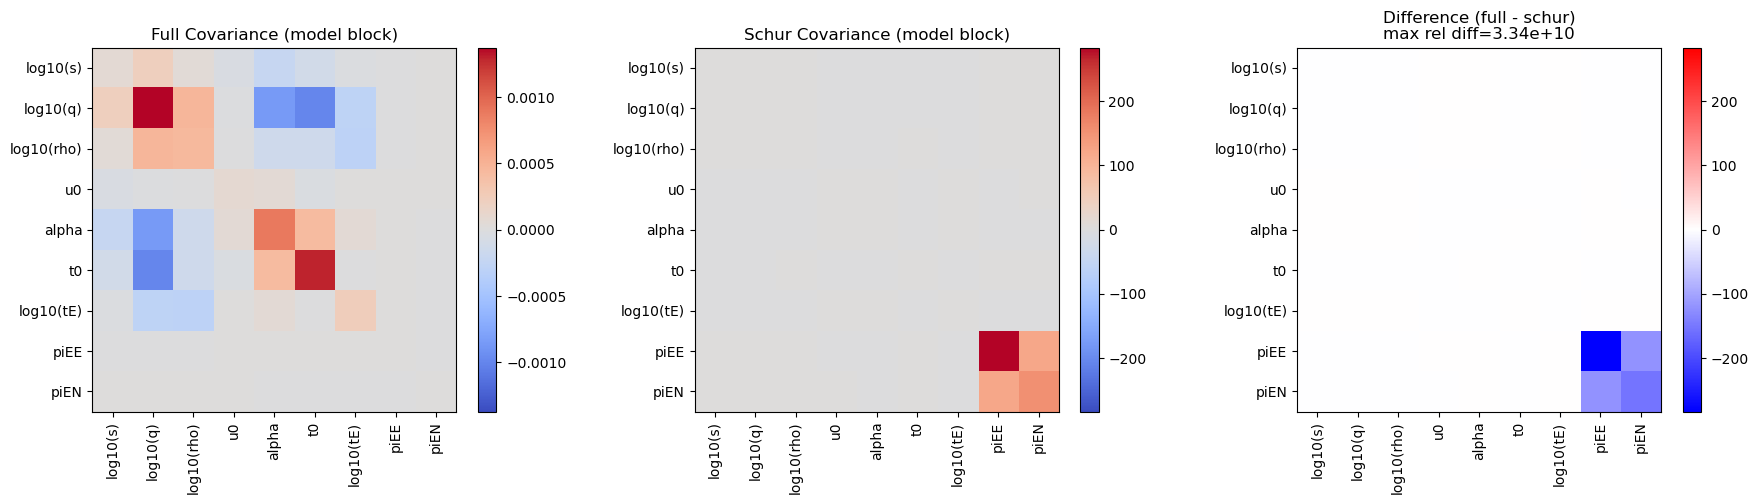

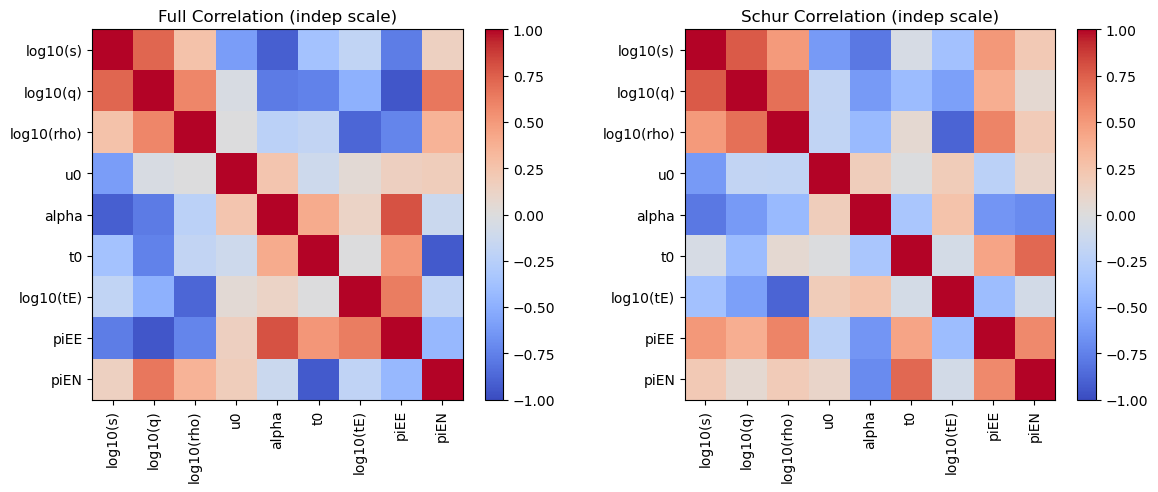

Diagonal (sigma) comparison:
param  full_sigma      schur_sigma     ratio(full/schur)
  log10(s)   8.2716e-03   9.6322e-03     0.859
  log10(q)   3.7035e-02   4.1204e-02     0.899
log10(rho)   2.1160e-02   2.7113e-02     0.780
        u0   8.7314e-03   9.3852e-03     0.930
     alpha   2.9754e-02   4.5723e-02     0.651
        t0   3.5891e-02   5.1418e-02     0.698
 log10(tE)   1.5626e-02   1.7506e-02     0.893
      piEE   9.2101e-05   1.6838e+01     0.000
      piEN   1.1264e-04   1.2443e+01     0.000


In [25]:
# === Parameter Covariance Comparison: Full Inverse vs Schur Alternative ===
import numpy as np, matplotlib.pyplot as plt

param_labels = ['log10(s)','log10(q)','log10(rho)','u0','alpha','t0','log10(tE)','piEE','piEN']

# Retrieve full inverse-based covariance (top-left block)
C_full = getattr(data_obj, 'full_covariance', None)
if C_full is None:
    raise RuntimeError('full_covariance not available; load data first.')
C_full_model = C_full[:len(param_labels), :len(param_labels)]

# Retrieve or compute Schur covariance alternative
C_schur = getattr(data_obj, 'schur_covariance_alt', None)
if C_schur is None:
    F = getattr(data_obj, 'full_fisher_matrix', None)
    if F is None:
        raise RuntimeError('full_fisher_matrix missing; cannot compute Schur alternative.')
    n = len(param_labels)
    F_mm = F[:n,:n]
    F_mf = F[:n,n:]
    F_fm = F[n:,:n]
    F_ff = F[n:,n:]
    # Invert F_ff robustly
    try:
        F_ff_inv = np.linalg.inv(F_ff)
    except np.linalg.LinAlgError:
        F_ff_inv = np.linalg.pinv(F_ff, rcond=1e-10)
    F_schur = F_mm - F_mf @ F_ff_inv @ F_fm
    try:
        C_schur = np.linalg.inv(F_schur)
    except np.linalg.LinAlgError:
        C_schur = np.linalg.pinv(F_schur, rcond=1e-10)

# Difference metrics
C_diff = C_full_model - C_schur
rel_max = np.max(np.abs(C_diff) / np.maximum(1e-30, np.abs(C_full_model)))

fig, axs = plt.subplots(1,3, figsize=(18,5))
# Independent color scaling (was shared) for the two covariance panels
v0 = np.max(np.abs(C_full_model))
im0 = axs[0].imshow(C_full_model, cmap='coolwarm', vmin=-v0, vmax=v0)
axs[0].set_title('Full Covariance (model block)')
v1 = np.max(np.abs(C_schur))
im1 = axs[1].imshow(C_schur, cmap='coolwarm', vmin=-v1, vmax=v1)
axs[1].set_title('Schur Covariance (model block)')
# Difference heatmap keeps its own scale
vd = np.max(np.abs(C_diff))
im2 = axs[2].imshow(C_diff, cmap='bwr', vmin=-vd, vmax=vd)
axs[2].set_title(f'Difference (full - schur)\nmax rel diff={rel_max:.2e}')
for ax in axs:
    ax.set_xticks(range(len(param_labels)))
    ax.set_yticks(range(len(param_labels)))
    ax.set_xticklabels(param_labels, rotation=90)
    ax.set_yticklabels(param_labels)
fig.colorbar(im0, ax=axs[0], fraction=0.046)
fig.colorbar(im1, ax=axs[1], fraction=0.046)
fig.colorbar(im2, ax=axs[2], fraction=0.046)
plt.tight_layout()
plt.show()

# Correlation matrices with independent scaling per panel
D_full = np.sqrt(np.abs(np.diag(C_full_model)))
D_schur = np.sqrt(np.abs(np.diag(C_schur)))
Corr_full = C_full_model / (D_full[:,None]*D_full[None,:])
Corr_schur = C_schur / (D_schur[:,None]*D_schur[None,:])

fig2, ax2 = plt.subplots(1,2, figsize=(12,5))
cm0 = np.max(np.abs(Corr_full))
img0 = ax2[0].imshow(Corr_full, cmap='coolwarm', vmin=-cm0, vmax=cm0)
ax2[0].set_title('Full Correlation (indep scale)')
cm1 = np.max(np.abs(Corr_schur))
img1 = ax2[1].imshow(Corr_schur, cmap='coolwarm', vmin=-cm1, vmax=cm1)
ax2[1].set_title('Schur Correlation (indep scale)')
for ax in ax2:
    ax.set_xticks(range(len(param_labels)))
    ax.set_yticks(range(len(param_labels)))
    ax.set_xticklabels(param_labels, rotation=90)
    ax.set_yticklabels(param_labels)
fig2.colorbar(img0, ax=ax2[0], fraction=0.046)
fig2.colorbar(img1, ax=ax2[1], fraction=0.046)
plt.tight_layout()
plt.show()

# Print concise diagonal comparison
print("Diagonal (sigma) comparison:")
print("param  full_sigma      schur_sigma     ratio(full/schur)")
for i,p in enumerate(param_labels):
    sf = D_full[i]
    ss = D_schur[i]
    print(f"{p:>10s}  {sf:11.4e}  {ss:11.4e}  {sf/ss:8.3f}")

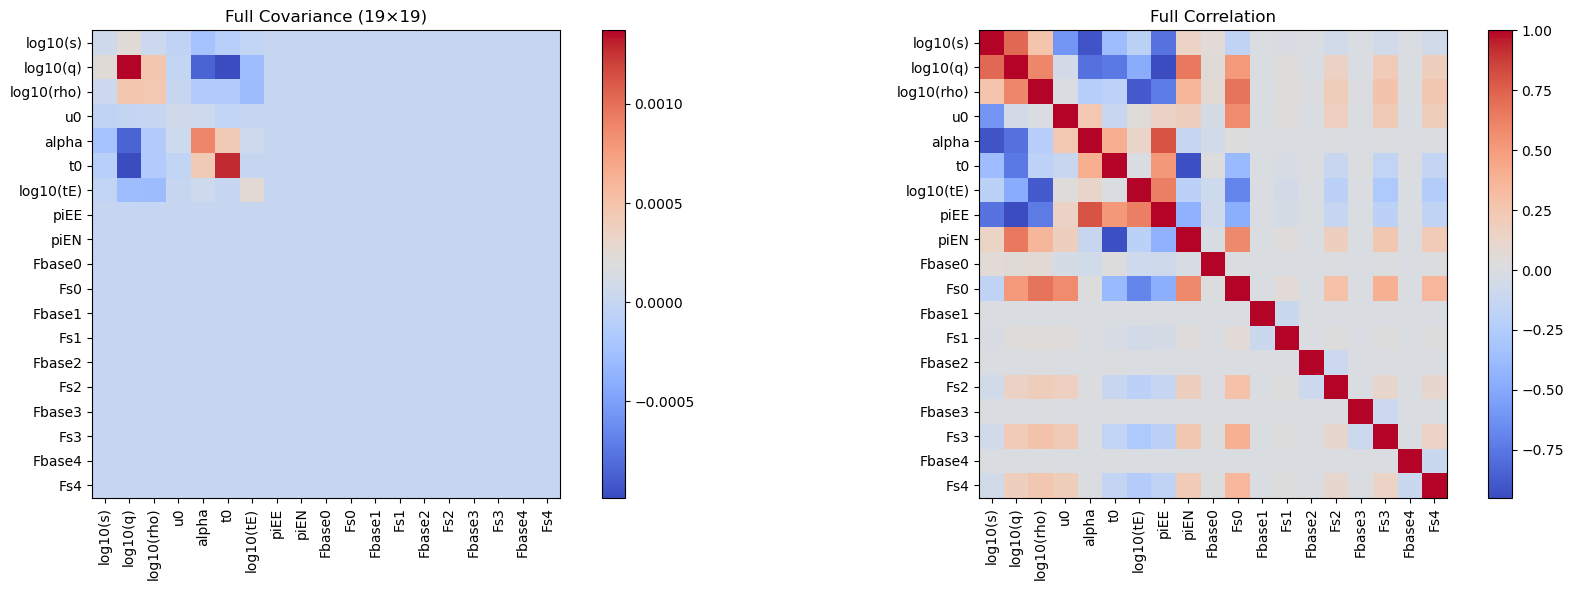

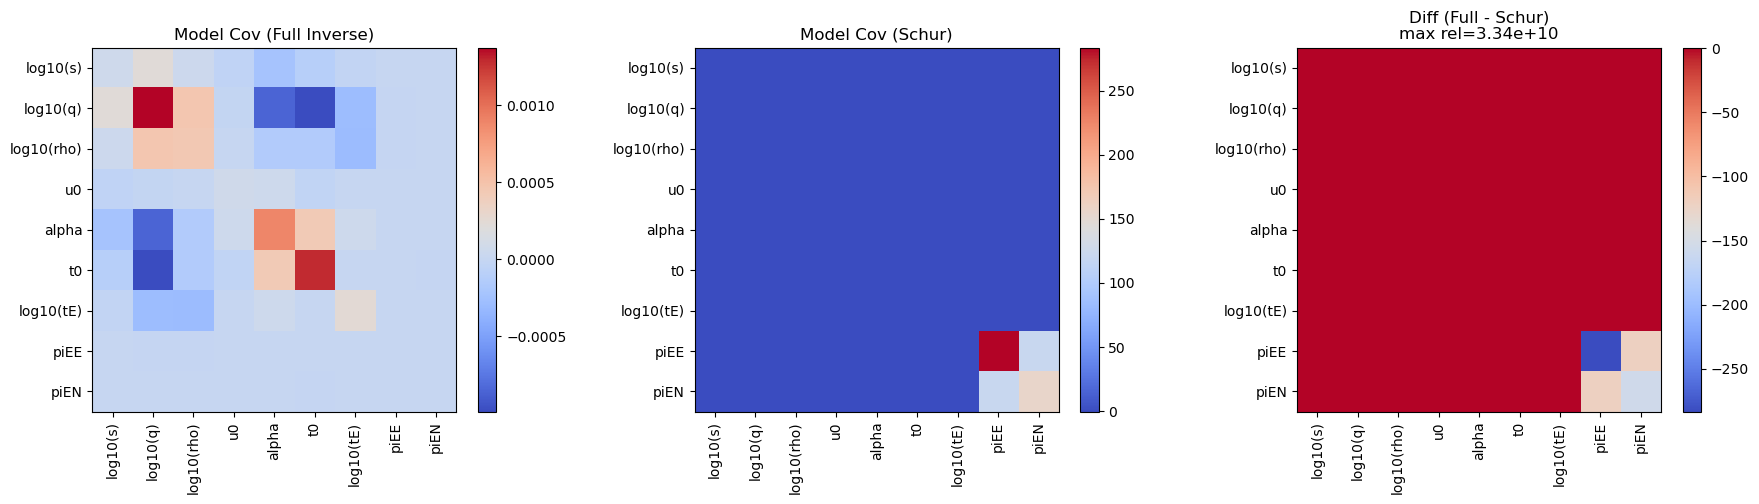

Full covariance diagonal (1-sigma):
 0 log10(s)  sigma= 8.271579e-03
 1 log10(q)  sigma= 3.703541e-02
 2 log10(rho)  sigma= 2.116043e-02
 3       u0  sigma= 8.731423e-03
 4    alpha  sigma= 2.975390e-02
 5       t0  sigma= 3.589098e-02
 6 log10(tE)  sigma= 1.562567e-02
 7     piEE  sigma= 9.210055e-05
 8     piEN  sigma= 1.126440e-04
 9   Fbase0  sigma= 8.624476e-06
10      Fs0  sigma= 1.466419e-04
11   Fbase1  sigma= 1.858063e-04
12      Fs1  sigma= 5.360535e-04
13   Fbase2  sigma= 1.098324e-04
14      Fs2  sigma= 3.322645e-04
15   Fbase3  sigma= 6.496203e-05
16      Fs3  sigma= 2.394318e-04
17   Fbase4  sigma= 6.567509e-05
18      Fs4  sigma= 2.369579e-04
Schur covariance diagonal (1-sigma):
 0 log10(s)  sigma= 9.632192e-03
 1 log10(q)  sigma= 4.120393e-02
 2 log10(rho)  sigma= 2.711281e-02
 3       u0  sigma= 9.385245e-03
 4    alpha  sigma= 4.572309e-02
 5       t0  sigma= 5.141818e-02
 6 log10(tE)  sigma= 1.750606e-02
 7     piEE  sigma= 1.683774e+01
 8     piEN  sigma= 1.244313e+

In [26]:
# === FULL Parameter Covariance (Model + Flux) ===
import numpy as np, matplotlib.pyplot as plt

full_C = getattr(data_obj, 'full_covariance', None)
if full_C is None:
    raise RuntimeError('full_covariance not available; load data first.')

n_model = 9
n_total = full_C.shape[0]
if n_total <= n_model:
    raise RuntimeError(f'Full covariance only has {n_total} rows; no flux params present.')

# Model param labels
model_labels = ['log10(s)','log10(q)','log10(rho)','u0','alpha','t0','log10(tE)','piEE','piEN']
# Flux param labels (generic baseline/source per filter 0..4)
flux_labels = ['Fbase0','Fs0','Fbase1','Fs1','Fbase2','Fs2','Fbase3','Fs3','Fbase4','Fs4']
# Trim flux labels if fewer than 10 flux params
flux_labels = flux_labels[:(n_total - n_model)]
all_labels = model_labels + flux_labels

# Full covariance heatmap
fig, axs = plt.subplots(1,2, figsize=(18,6))
C = full_C
v = np.max(np.abs(C))
im = axs[0].imshow(C, cmap='coolwarm')  #, vmin=-v, vmax=v)
axs[0].set_title('Full Covariance (19×19)')
axs[0].set_xticks(range(n_total))
axs[0].set_yticks(range(n_total))
axs[0].set_xticklabels(all_labels, rotation=90)
axs[0].set_yticklabels(all_labels)
fig.colorbar(im, ax=axs[0], fraction=0.046)

# Correlation matrix
D = np.sqrt(np.abs(np.diag(C)))
with np.errstate(divide='ignore', invalid='ignore'):
    Corr = C / (D[:,None]*D[None,:])
    Corr[np.isnan(Corr)] = 0.0
cm = 1.0
im2 = axs[1].imshow(Corr, cmap='coolwarm')  #, vmin=-cm, vmax=cm)
axs[1].set_title('Full Correlation')
axs[1].set_xticks(range(n_total))
axs[1].set_yticks(range(n_total))
axs[1].set_xticklabels(all_labels, rotation=90)
axs[1].set_yticklabels(all_labels)
fig.colorbar(im2, ax=axs[1], fraction=0.046)
plt.tight_layout()
plt.show()

# Optional: model block difference vs Schur alternative (diagnostic)
C_model = C[:n_model,:n_model]
C_schur = getattr(data_obj, 'schur_covariance_alt', None)
if C_schur is not None and C_schur.shape == C_model.shape:
    diff = C_model - C_schur
    rel = np.max(np.abs(diff)/np.maximum(1e-30, np.abs(C_model)))
    fig2, ax2 = plt.subplots(1,3, figsize=(18,5))
    #v_m = np.max(np.abs(np.concatenate([C_model.flatten(), C_schur.flatten()])))
    a0 = ax2[0].imshow(C_model, cmap='coolwarm')  #, vmin=-v_m, vmax=v_m)
    ax2[0].set_title('Model Cov (Full Inverse)')
    a1 = ax2[1].imshow(C_schur, cmap='coolwarm')  #, vmin=-v_m, vmax=v_m)
    ax2[1].set_title('Model Cov (Schur)')
    #v_d = np.max(np.abs(diff))
    a2 = ax2[2].imshow(diff, cmap='coolwarm')  #, vmin=-v_d, vmax=v_d)
    ax2[2].set_title(f'Diff (Full - Schur)\nmax rel={rel:.2e}')
    for ax in ax2:
        ax.set_xticks(range(n_model))
        ax.set_yticks(range(n_model))
        ax.set_xticklabels(model_labels, rotation=90)
        ax.set_yticklabels(model_labels)
    fig2.colorbar(a0, ax=ax2[0], fraction=0.046)
    fig2.colorbar(a1, ax=ax2[1], fraction=0.046)
    fig2.colorbar(a2, ax=ax2[2], fraction=0.046)
    plt.tight_layout()
    plt.show()

# Print diagonal (all params)
print('Full covariance diagonal (1-sigma):')
for i,(lab,sig2) in enumerate(zip(all_labels, np.diag(C))):
    sigma = np.sqrt(abs(sig2))
    print(f"{i:2d} {lab:>8s}  sigma={sigma: .6e}")
    
# print Schur diagonal
print('Schur covariance diagonal (1-sigma):')
C_schur = getattr(data_obj, 'schur_covariance_alt', None)
if C_schur is not None:
    for i,(lab,sig2) in enumerate(zip(all_labels, np.diag(C_schur))):
        sigma = np.sqrt(abs(sig2))
        print(f"{i:2d} {lab:>8s}  sigma={sigma: .6e}")

In [27]:
# First, let's diagnose what Fisher matrix information we have available
print("=== Fisher Matrix Diagnostic ===")
print(f"data_obj has model_derivatives: {hasattr(data_obj, 'model_derivatives')}")
if hasattr(data_obj, 'model_derivatives'):
    print(f"  model_derivatives shape: {data_obj.model_derivatives.shape if data_obj.model_derivatives is not None else 'None'}")

print(f"data_obj has fisher_matrix (marginalized): {hasattr(data_obj, 'fisher_matrix')}")
if hasattr(data_obj, 'fisher_matrix'):
    print(f"  fisher_matrix shape: {data_obj.fisher_matrix.shape if data_obj.fisher_matrix is not None else 'None'}")

print(f"data_obj has full_fisher_matrix: {hasattr(data_obj, 'full_fisher_matrix')}")
if hasattr(data_obj, 'full_fisher_matrix'):
    print(f"  full_fisher_matrix shape: {data_obj.full_fisher_matrix.shape if data_obj.full_fisher_matrix is not None else 'None'}")

print(f"data_obj has full_covariance: {hasattr(data_obj, 'full_covariance')}")
if hasattr(data_obj, 'full_covariance'):
    print(f"  full_covariance shape: {data_obj.full_covariance.shape if data_obj.full_covariance is not None else 'None'}")

print(f"data_obj has model_covariance: {hasattr(data_obj, 'model_covariance')}")
if hasattr(data_obj, 'model_covariance'):
    print(f"  model_covariance shape: {data_obj.model_covariance.shape if data_obj.model_covariance is not None else 'None'}")

print(f"data_obj has n_flux_params: {hasattr(data_obj, 'n_flux_params')}")
if hasattr(data_obj, 'n_flux_params'):
    print(f"  n_flux_params: {data_obj.n_flux_params}")

# Show the difference in uncertainties
if hasattr(data_obj, 'full_covariance') and data_obj.full_covariance is not None:
    full_model_unc = np.sqrt(np.diag(data_obj.full_covariance[:9, :9]))
    print(f"\nUncertainty comparison:")
    print(f"Marginalized Fisher uncertainties: {data_obj.model_parameter_uncertainties}")
    print(f"Full Fisher uncertainties (model block): {full_model_unc}")
    print(f"Ratio (full/marginalized): {full_model_unc / data_obj.model_parameter_uncertainties}")

print("==========================")

=== Fisher Matrix Diagnostic ===
data_obj has model_derivatives: True
  model_derivatives shape: (54438, 9)
data_obj has fisher_matrix (marginalized): True
  fisher_matrix shape: (9, 9)
data_obj has full_fisher_matrix: True
  full_fisher_matrix shape: (19, 19)
data_obj has full_covariance: True
  full_covariance shape: (19, 19)
data_obj has model_covariance: True
  model_covariance shape: (9, 9)
data_obj has n_flux_params: True
  n_flux_params: 10

Uncertainty comparison:
Marginalized Fisher uncertainties: [8.27157907e-03 3.70354059e-02 2.11604326e-02 8.73142330e-03
 2.97538999e-02 3.58909814e-02 1.56256700e-02 9.21005549e-05
 1.12644029e-04]
Full Fisher uncertainties (model block): [8.27157907e-03 3.70354059e-02 2.11604326e-02 8.73142330e-03
 2.97538999e-02 3.58909814e-02 1.56256700e-02 9.21005549e-05
 1.12644029e-04]
Ratio (full/marginalized): [1. 1. 1. 1. 1. 1. 1. 1. 1.]


## 7. Visualization

Create plots to visualize the data and posterior samples:

### Plot Lightcurve Data

Found fs values: [0.00407102, 0.00101059, 0.00289278, 0.00273439, 0.00238946]
Filter 0: fs = 0.004071, mag range = -0.987 to 29.544
Filter 1: fs = 0.001011, mag range = -25.610 to 22.266
Filter 2: fs = 0.002893, mag range = -4.258 to 10.246
Filter 3: fs = 0.002734, mag range = -2.279 to 6.168
Filter 0: fs = 0.004071, mag range = -0.987 to 29.544
Filter 1: fs = 0.001011, mag range = -25.610 to 22.266
Filter 2: fs = 0.002893, mag range = -4.258 to 10.246
Filter 3: fs = 0.002734, mag range = -2.279 to 6.168
Filter 4: fs = 0.002389, mag range = -2.663 to 6.475
Filter 4: fs = 0.002389, mag range = -2.663 to 6.475


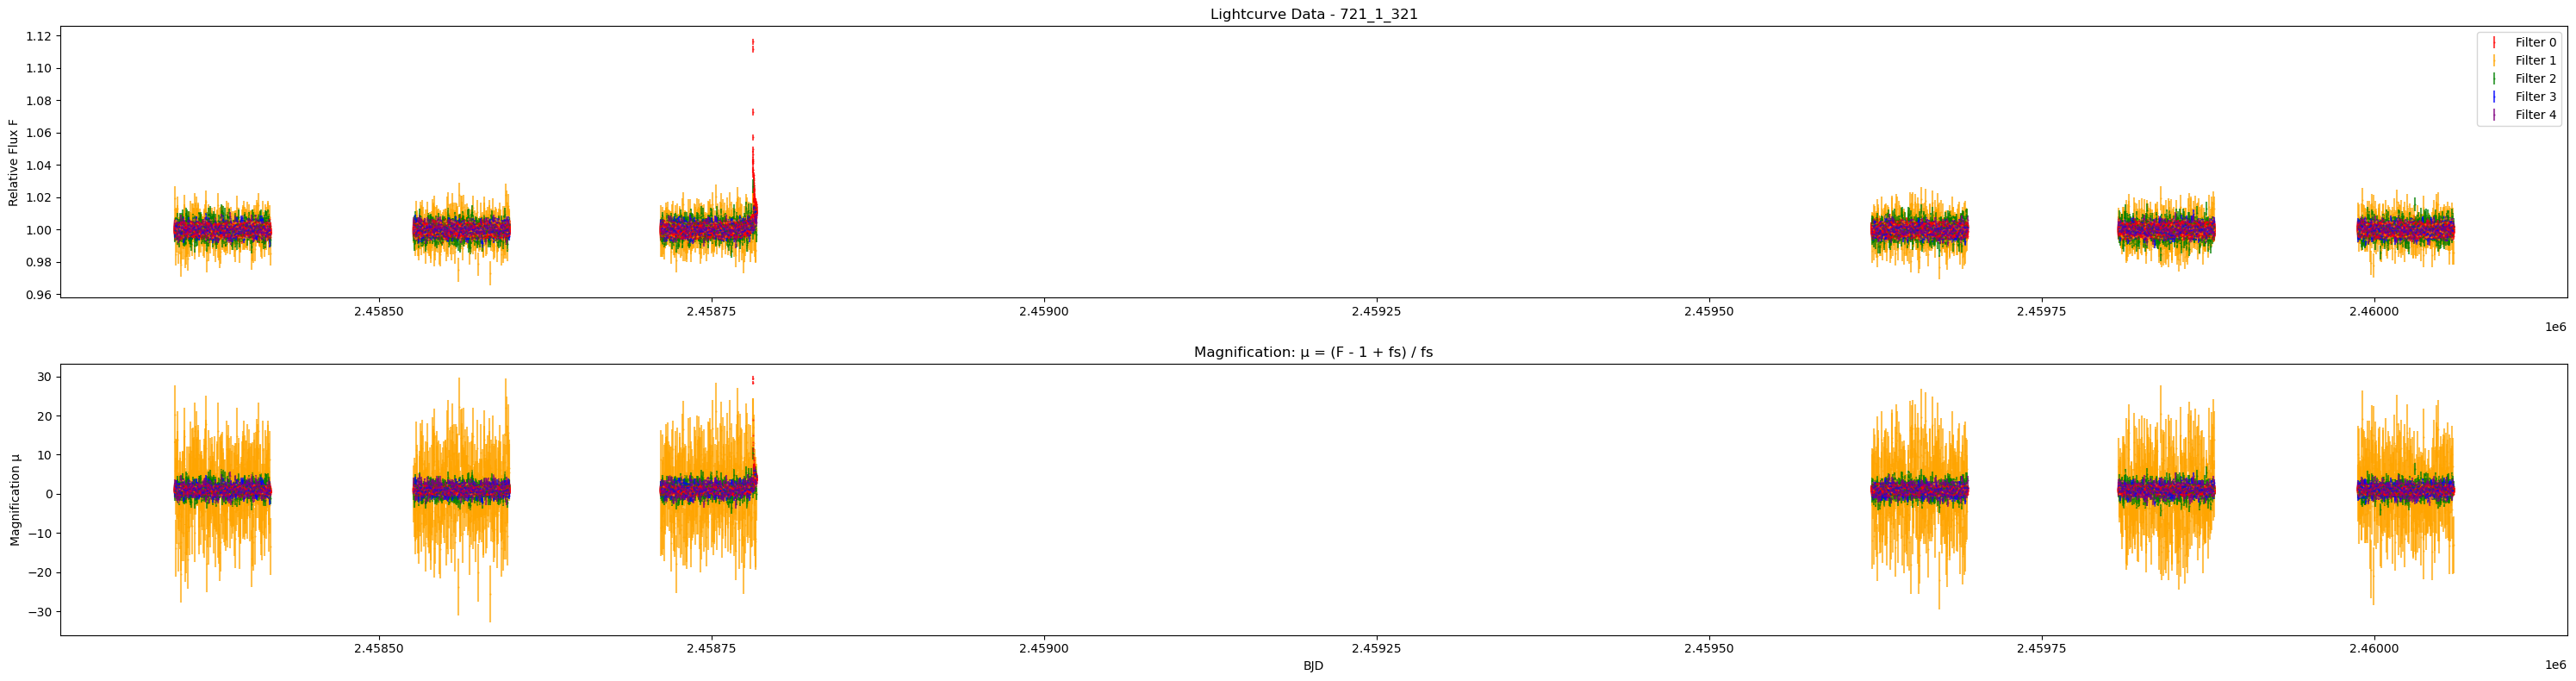


Magnification calculated using μ = (F - 1 + fs) / fs
Error propagation: σ_μ = σ_F / fs


In [28]:
if 'combined_df' in locals():
    # First, extract fs values from the lightcurve file header
    fs_values = {}
    with open(full_lc_path, 'r') as f:
        for line in f:
            if line.startswith('#fs'):
                # Parse fs line: format is typically "#fs 0.123 0.456 0.789 ..." (fs values for each filter)
                fs_parts = line.strip().split()[1:]  # Skip the "#fs" part
                try:
                    fs_list = [float(x) for x in fs_parts]
                    print(f"Found fs values: {fs_list}")
                    
                    # Map to observatory codes (assuming they correspond to filter indices)
                    for i, fs_val in enumerate(fs_list):
                        fs_values[i] = fs_val
                    break
                except ValueError:
                    print(f"Could not parse fs values from: {line.strip()}")
            elif not line.startswith('#'):
                # Hit data, stop looking for header
                break
    
    if not fs_values:
        print("Warning: No fs values found in header. Cannot calculate proper magnification.")
        print("Falling back to relative flux plots only.")
    
    plt.figure(figsize=(30, 8))
    
    # Colors for different observatories (generic since we don't know band names)
    colors = {0: 'red', 1: 'orange', 2: 'green', 3: 'blue', 4: 'purple'}
    
    for obs_code in combined_df['observatory_code'].unique():
        obs_data = combined_df[combined_df['observatory_code'] == obs_code]
        color = colors.get(obs_code, 'black')
        label = f'Filter {obs_code}'
        
        # Plot relative flux
        plt.subplot(2, 1, 1)
        plt.errorbar(obs_data['BJD'], obs_data['measured_relative_flux'], 
                    yerr=obs_data['measured_relative_flux_error'],
                    fmt='.', color=color, label=label, alpha=0.7, markersize=1)
        
        # Plot magnification (if we have fs values)
        plt.subplot(2, 1, 2)
        if obs_code in fs_values:
            fs = fs_values[obs_code]
            F = obs_data['measured_relative_flux']
            F_err = obs_data['measured_relative_flux_error']
            
            # Calculate magnification: μ = (F - 1 + fs) / fs
            # Since F = fs*μ + (1-fs) and we want μ, rearrange: μ = (F - (1-fs)) / fs = (F - 1 + fs) / fs
            magnification = (F - 1 + fs) / fs
            
            # Error propagation: if μ = (F - 1 + fs) / fs, then dμ/dF = 1/fs
            # So σ_μ = σ_F / fs
            mag_err = F_err / fs
            
            plt.errorbar(obs_data['BJD'], magnification, yerr=mag_err,
                        fmt='.', color=color, alpha=0.7, markersize=1)
            
            print(f"Filter {obs_code}: fs = {fs:.6f}, mag range = {magnification.min():.3f} to {magnification.max():.3f}")
        else:
            print(f"Filter {obs_code}: No fs value found, skipping magnification plot")
    
    plt.subplot(2, 1, 1)
    plt.ylabel('Relative Flux F')
    plt.legend()
    plt.title(f'Lightcurve Data - {event_name}' if event_name else 'Lightcurve Data')
    
    plt.subplot(2, 1, 2)
    plt.xlabel('BJD')
    if fs_values:
        plt.ylabel('Magnification μ')
        #plt.yscale('log')
        plt.title('Magnification: μ = (F - 1 + fs) / fs')
    else:
        plt.ylabel('No magnification (fs values missing)')
        plt.text(0.5, 0.5, 'Cannot calculate magnification\nwithout fs values from header', 
                transform=plt.gca().transAxes, ha='center', va='center', fontsize=12)
    
    plt.tight_layout()
    plt.show()
    
    if fs_values:
        print(f"\nMagnification calculated using μ = (F - 1 + fs) / fs")
        print(f"Error propagation: σ_μ = σ_F / fs")
else:
    print("No lightcurve data to plot. Please load data first.")

In [29]:
# checking the columns were loaded correctly
for obs_code in combined_df['observatory_code'].unique():
    obs_data = combined_df[combined_df['observatory_code'] == obs_code]
    F = obs_data['measured_relative_flux']
    F_err = obs_data['measured_relative_flux_error']
    print(f"Filter {obs_code}: F = {F.values[0]:.6f}, F_err = {F_err.values[0]:.6f}")

Filter 0: F = 0.999214, F_err = 0.001872
Filter 1: F = 1.005033, F_err = 0.007399
Filter 2: F = 0.999668, F_err = 0.004374
Filter 3: F = 0.999819, F_err = 0.002586
Filter 4: F = 1.000849, F_err = 0.002614


### Corner Plot WITHOUT Fisher Annotations

This creates a clean corner plot without any Fisher matrix overlays:

Samples shape: (1000000, 9)
Sample statistics (first few parameters):
  Param 0: mean=0.106, std=0.021, range=[0.047, 0.164]
  Param 1: mean=-0.499, std=0.088, range=[-0.830, -0.225]
  Param 2: mean=-2.724, std=0.048, range=[-2.957, -2.569]
  Param 3: mean=0.186, std=0.020, range=[0.112, 0.262]
  Param 4: mean=0.101, std=0.068, range=[0.000, 0.355]
  Param 5: mean=2458780.743, std=0.066, range=[2458780.477, 2458781.018]
  Param 6: mean=0.731, std=0.044, range=[0.601, 0.930]
  Param 7: mean=-0.002, std=4.873, range=[-20.830, 24.186]
  Param 8: mean=-1.920, std=4.800, range=[-25.687, 18.685]

Raw truth values (linear space):
  Truth 0: 1.192541
  Truth 1: 0.307936
  Truth 2: 0.001965
  Truth 3: 0.211575
  Truth 4: 0.197640
  Truth 5: 2458780.697566
  Truth 6: 5.143039
  Truth 7: -0.036441
  Truth 8: 0.085357

Converting truth values to log space for parameters: [0, 1, 2, 6]
  Param 0: 1.192541 -> log10(1.192541) = 0.076473
  Param 1: 0.307936 -> log10(0.307936) = -0.511540
  Param 2: 0.0

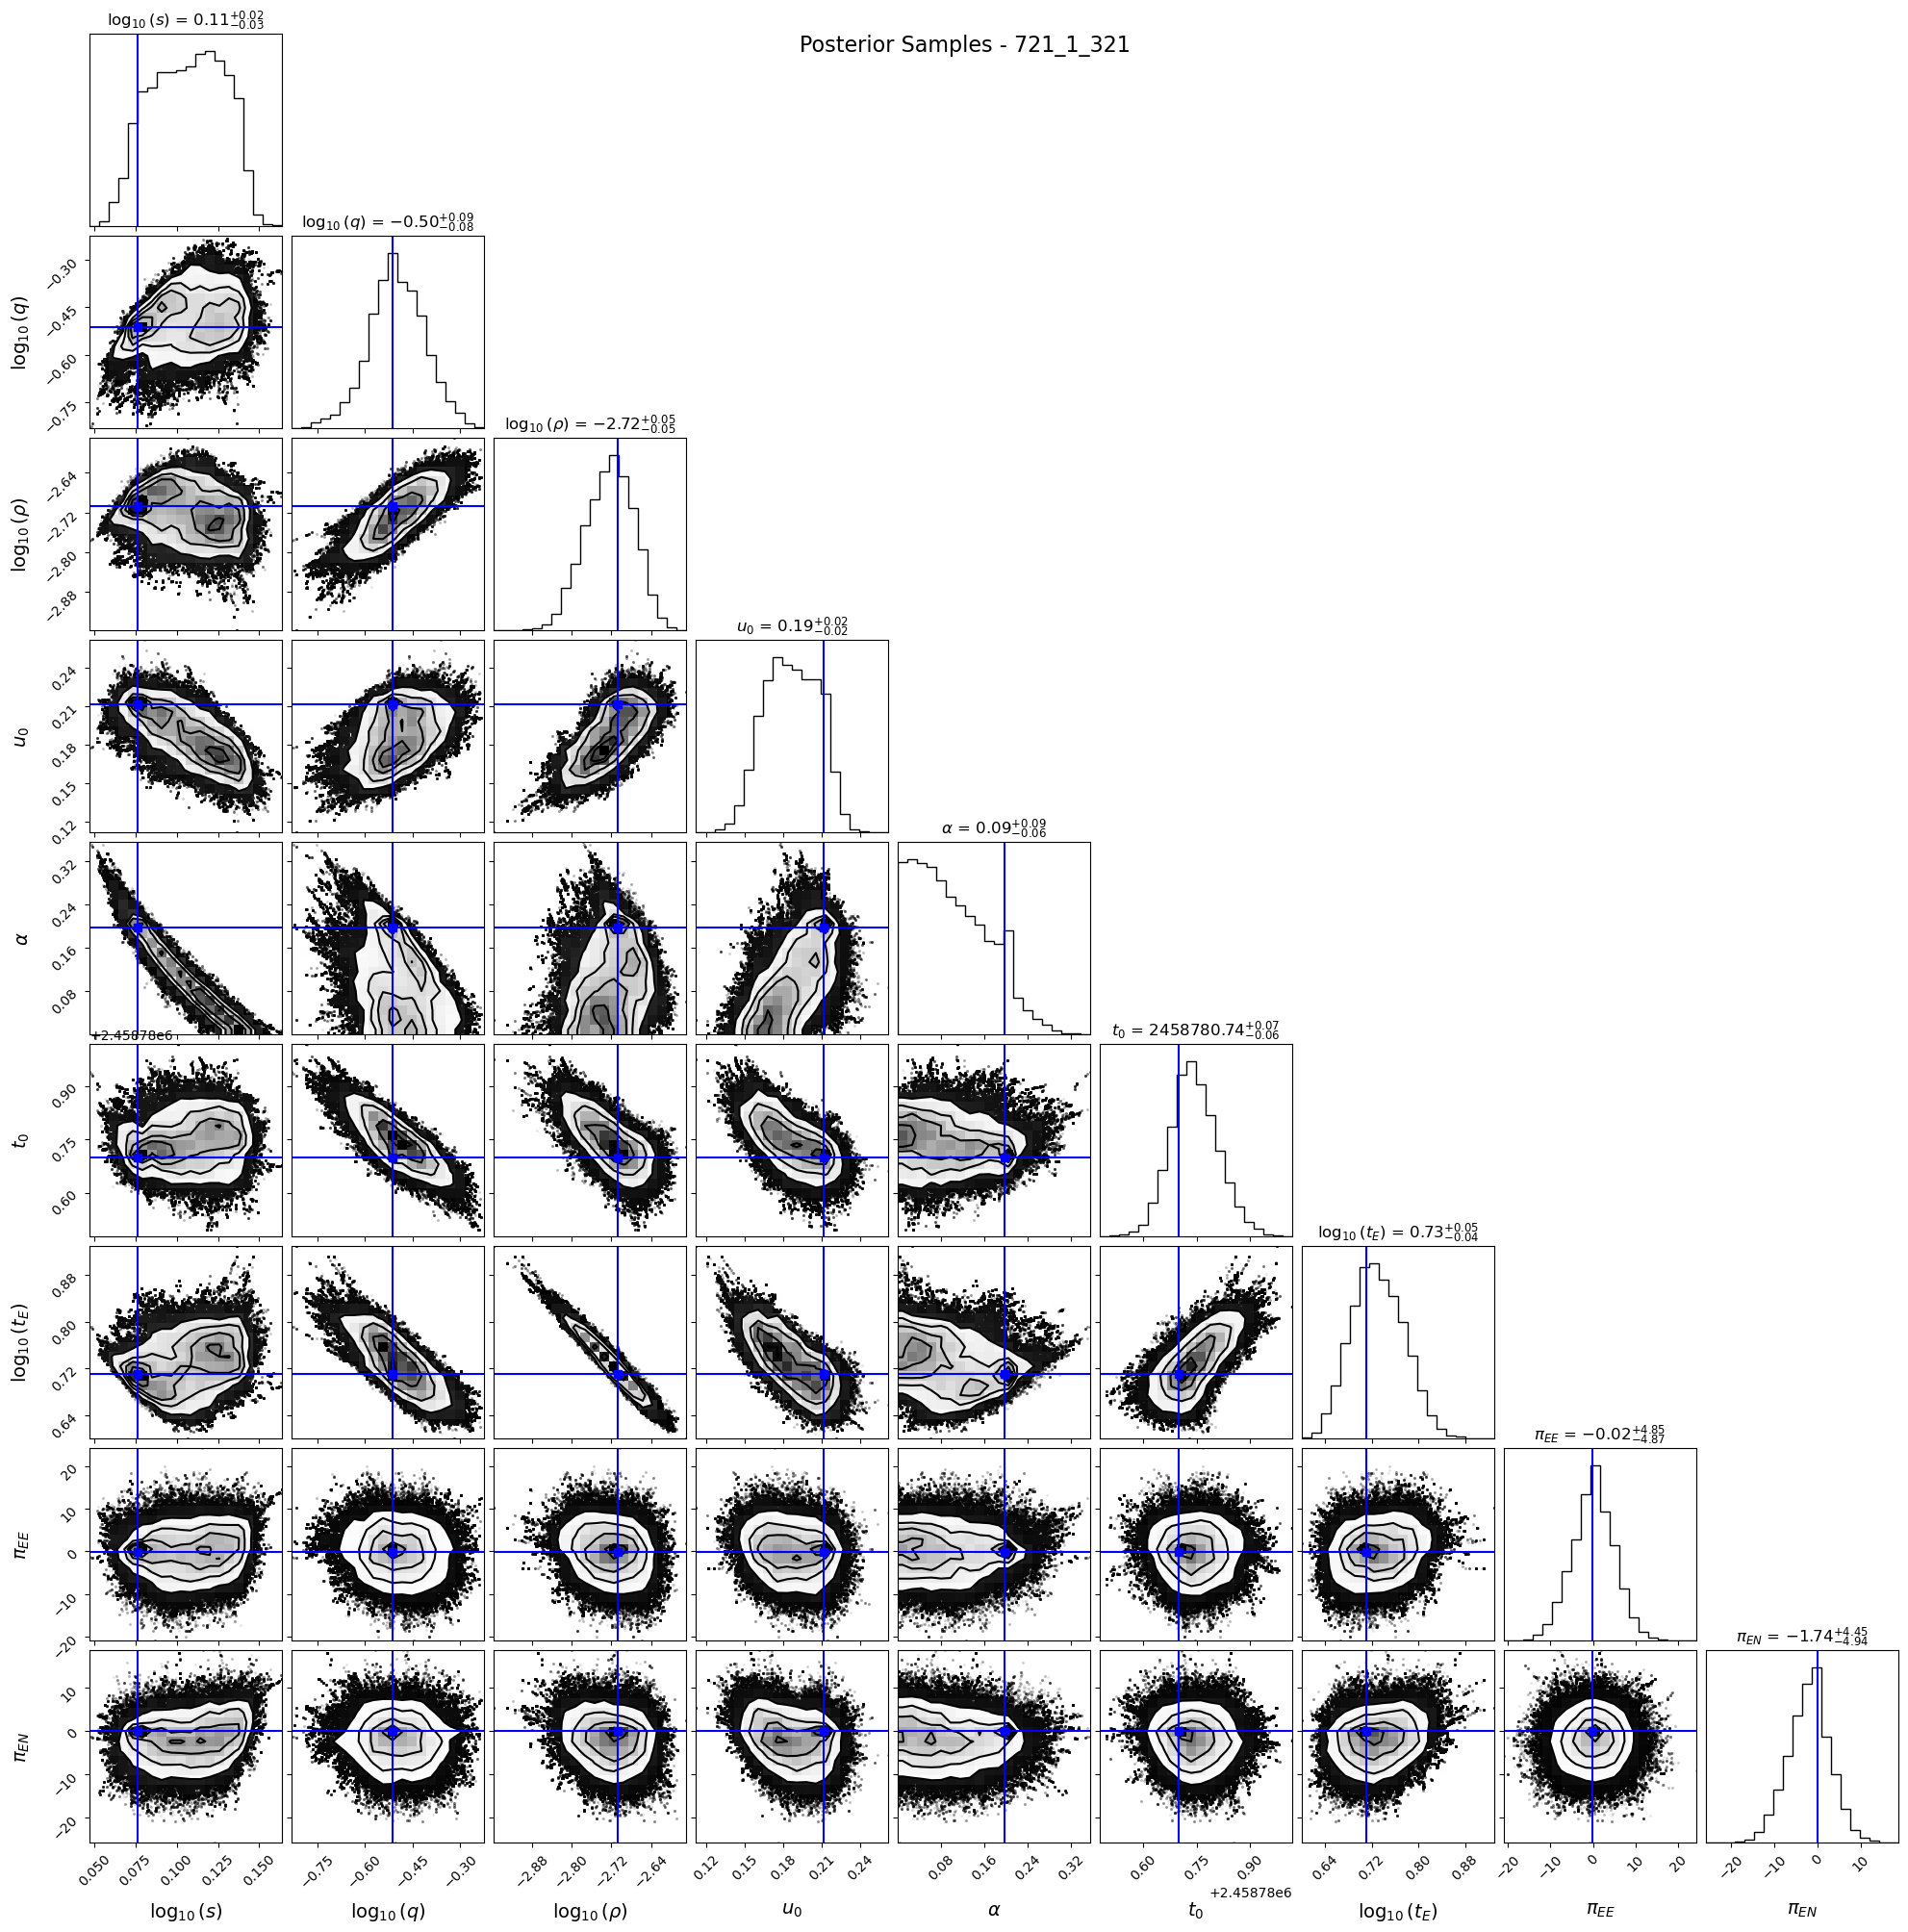

Corner plot created with correct parameter labels (s, q, rho, tE in log space)
Truth values converted to log space for log parameters and displayed in blue


In [30]:
if samples is not None:
    # First, let's figure out what we're actually sampling by looking at the samples and truths
    print(f"Samples shape: {samples.shape}")
    print(f"Sample statistics (first few parameters):")
    for i in range(min(9, samples.shape[1])):
        mean_val = np.mean(samples[:, i])
        std_val = np.std(samples[:, i])
        min_val = np.min(samples[:, i])
        max_val = np.max(samples[:, i])
        print(f"  Param {i}: mean={mean_val:.3f}, std={std_val:.3f}, range=[{min_val:.3f}, {max_val:.3f}]")
    
    # Check if we have truth values to help identify parameters
    truth_values = None
    if truths is not None and 'params' in truths:
        truth_values_raw = truths['params'][:samples.shape[1]]
        print(f"\nRaw truth values (linear space):")
        for i, truth in enumerate(truth_values_raw):
            print(f"  Truth {i}: {truth:.6f}")
        
        # Convert truth values to match the sampling space
        # s, q, rho, tE (indices 0, 1, 2, 6) are sampled in log space
        truth_values = truth_values_raw.copy()
        log_param_indices = [0, 1, 2, 6]  # s, q, rho, tE
        
        print(f"\nConverting truth values to log space for parameters: {log_param_indices}")
        for idx in log_param_indices:
            if idx < len(truth_values):
                original_val = truth_values[idx]
                if original_val > 0:  # Can only take log of positive values
                    truth_values[idx] = np.log10(original_val)
                    print(f"  Param {idx}: {original_val:.6f} -> log10({original_val:.6f}) = {truth_values[idx]:.6f}")
                else:
                    print(f"  Warning: Param {idx} has non-positive value {original_val}, cannot take log")
                    truth_values[idx] = np.nan
    
    # Parameter labels - s, q, rho, and tE are ALWAYS sampled in log space
    if samples.shape[1] == 12:  # LOM enabled
        labels = [
            r"$\log_{10}(s)$",      # 0: separation (always log)
            r"$\log_{10}(q)$",      # 1: mass ratio (always log)
            r"$\log_{10}(\rho)$",   # 2: finite source (always log)
            r"$u_0$",               # 3: impact parameter (linear)
            r"$\alpha$",            # 4: trajectory angle (linear)
            r"$t_0$",               # 5: time of closest approach (linear)
            r"$\log_{10}(t_E)$",    # 6: Einstein crossing time (always log)
            r"$\pi_{EE}$",          # 7: parallax east (linear)
            r"$\pi_{EN}$",          # 8: parallax north (linear)
            r"$i$",                 # 9: inclination (linear)
            r"$\phi$",              # 10: phase (linear)
            r"$P$"                  # 11: period (linear)
        ]
                
    else:  # 9 parameters (no LOM)
        labels = [
            r"$\log_{10}(s)$",      # 0: separation (always log)
            r"$\log_{10}(q)$",      # 1: mass ratio (always log)
            r"$\log_{10}(\rho)$",   # 2: finite source (always log)
            r"$u_0$",               # 3: impact parameter (linear)
            r"$\alpha$",            # 4: trajectory angle (linear)
            r"$t_0$",               # 5: time of closest approach (linear)
            r"$\log_{10}(t_E)$",    # 6: Einstein crossing time (always log)
            r"$\pi_{EE}$",          # 7: parallax east (linear)
            r"$\pi_{EN}$"           # 8: parallax north (linear)
        ]
    
    # Trim labels to match actual number of parameters
    labels = labels[:samples.shape[1]]
    
    print(f"\nParameter labels (s, q, rho, tE always in log space): {labels}")
    print(f"Creating corner plot for {samples.shape[1]} parameters...")
    print(f"Using {len(samples)} samples")
    
    # Create corner plot with corrected labels and blue truth lines
    fig = corner.corner(
        samples,
        labels=labels,
        truths=truth_values,
        truth_color='blue',  # Changed from red to blue
        show_titles=True,
        title_kwargs={"fontsize": 12},
        label_kwargs={"fontsize": 14}
    )
    
    plt.suptitle(f'Posterior Samples - {event_name}' if event_name else 'Posterior Samples', 
                fontsize=16, y=0.98)
    plt.show()
    
    print("Corner plot created with correct parameter labels (s, q, rho, tE in log space)")
    print("Truth values converted to log space for log parameters and displayed in blue")
    
else:
    print("No posterior samples available for corner plot.")
    print("Run the sampler first to generate samples, then load them using the paths at the top.")

### Fisher Matrix Visualization

## 8. Fisher Corner Overlay

Make that same corner plot from section 6, but overlay the uncertainties as dashed lines above and below the truth, on the 1d histograms, and 1 sigma confidence elipses on the 2D histograms.

In [31]:
# Diagnostic: Check Fisher uncertainties in detail
print("=== Fisher Uncertainty Diagnostic ===")

if hasattr(data_obj, 'full_covariance') and data_obj.full_covariance is not None:
    model_fisher_cov = data_obj.full_covariance[:9, :9]
    model_fisher_unc = np.sqrt(np.diag(model_fisher_cov))
    
    param_names_short = ['log10(s)', 'log10(q)', 'log10(rho)', 'u0', 'alpha', 't0', 'log10(tE)', 'piEE', 'piEN']
    
    print("Fisher uncertainties in detail:")
    for i, (name, unc) in enumerate(zip(param_names_short, model_fisher_unc)):
        print(f"  {i}: {name}: {unc:.10f}")
    
    # Check if any uncertainties are extremely small
    tiny_unc = model_fisher_unc < 1e-8
    if np.any(tiny_unc):
        print(f"\nExtremely small uncertainties detected:")
        for i in np.where(tiny_unc)[0]:
            print(f"  {param_names_short[i]}: {model_fisher_unc[i]:.2e}")
    
    # Check parameter ranges from samples for comparison
    if 'samples' in locals() and samples is not None:
        print(f"\nSample standard deviations for comparison:")
        for i in range(min(9, samples.shape[1])):
            sample_std = np.std(samples[:, i])
            fisher_unc = model_fisher_unc[i]
            ratio = sample_std / fisher_unc if fisher_unc > 0 else np.inf
            print(f"  {i}: {param_names_short[i]}: sample_std={sample_std:.6f}, fisher_unc={fisher_unc:.6f}, ratio={ratio:.1f}")
    
print("=====================================")

# Also check what truth values we're using
if 'truths' in locals() and truths is not None:
    print("\nTruth values being used:")
    if 'params' in truths:
        truth_values_raw = truths['params'][:9]
        log_param_indices = [0, 1, 2, 6]  # s, q, rho, tE
        
        for i, truth in enumerate(truth_values_raw):
            if i in log_param_indices:
                log_truth = np.log10(truth) if truth > 0 else np.nan
                print(f"  {i}: {param_names_short[i]}: raw={truth:.6f}, log={log_truth:.6f}")
            else:
                print(f"  {i}: {param_names_short[i]}: {truth:.6f}")

=== Fisher Uncertainty Diagnostic ===
Fisher uncertainties in detail:
  0: log10(s): 0.0082715791
  1: log10(q): 0.0370354059
  2: log10(rho): 0.0211604326
  3: u0: 0.0087314233
  4: alpha: 0.0297538999
  5: t0: 0.0358909814
  6: log10(tE): 0.0156256700
  7: piEE: 0.0000921006
  8: piEN: 0.0001126440

Sample standard deviations for comparison:
  0: log10(s): sample_std=0.021447, fisher_unc=0.008272, ratio=2.6
  1: log10(q): sample_std=0.087659, fisher_unc=0.037035, ratio=2.4
  2: log10(rho): sample_std=0.048370, fisher_unc=0.021160, ratio=2.3
  3: u0: sample_std=0.020276, fisher_unc=0.008731, ratio=2.3
  4: alpha: sample_std=0.067523, fisher_unc=0.029754, ratio=2.3
  5: t0: sample_std=0.066107, fisher_unc=0.035891, ratio=1.8
  6: log10(tE): sample_std=0.044113, fisher_unc=0.015626, ratio=2.8
  7: piEE: sample_std=4.873464, fisher_unc=0.000092, ratio=52914.6
  8: piEN: sample_std=4.799622, fisher_unc=0.000113, ratio=42608.8

Truth values being used:
  0: log10(s): raw=1.192541, log=0.07

### Fisher Corner Plot - Display in Notebook

Test the new `return_figure=True` option to display the Fisher corner plot directly in the notebook:

Creating corrected Fisher corner plot with consistent parameter spaces...
Using FULL-INVERSE block covariance for corner plot (Schur not available or disabled).
Truth values that will be displayed:
  log10(s): linear=1.192541, log=0.076473, σ(full)=0.008272, σ(active)=0.008272
  log10(q): linear=0.307936, log=-0.511540, σ(full)=0.037035, σ(active)=0.037035
  log10(rho): linear=0.001965, log=-2.706582, σ(full)=0.021160, σ(active)=0.021160
  u0: 0.211575, σ(full)=0.008731, σ(active)=0.008731
  alpha: 0.197640, σ(full)=0.029754, σ(active)=0.029754
  t0: 2458780.697566, σ(full)=0.035891, σ(active)=0.035891
  log10(tE): linear=5.143039, log=0.711220, σ(full)=0.015626, σ(active)=0.015626
  piEE: -0.036441, σ(full)=0.000092, σ(active)=0.000092
  piEN: 0.085357, σ(full)=0.000113, σ(active)=0.000113
Checking for log parameter: s
Replacing $\log_{10}s$ with log10
Checking for log parameter: q
Replacing $\log_{10}q$ with log10
Checking for log parameter: rho
Replacing $\log_{10}{\rho}$ with log10

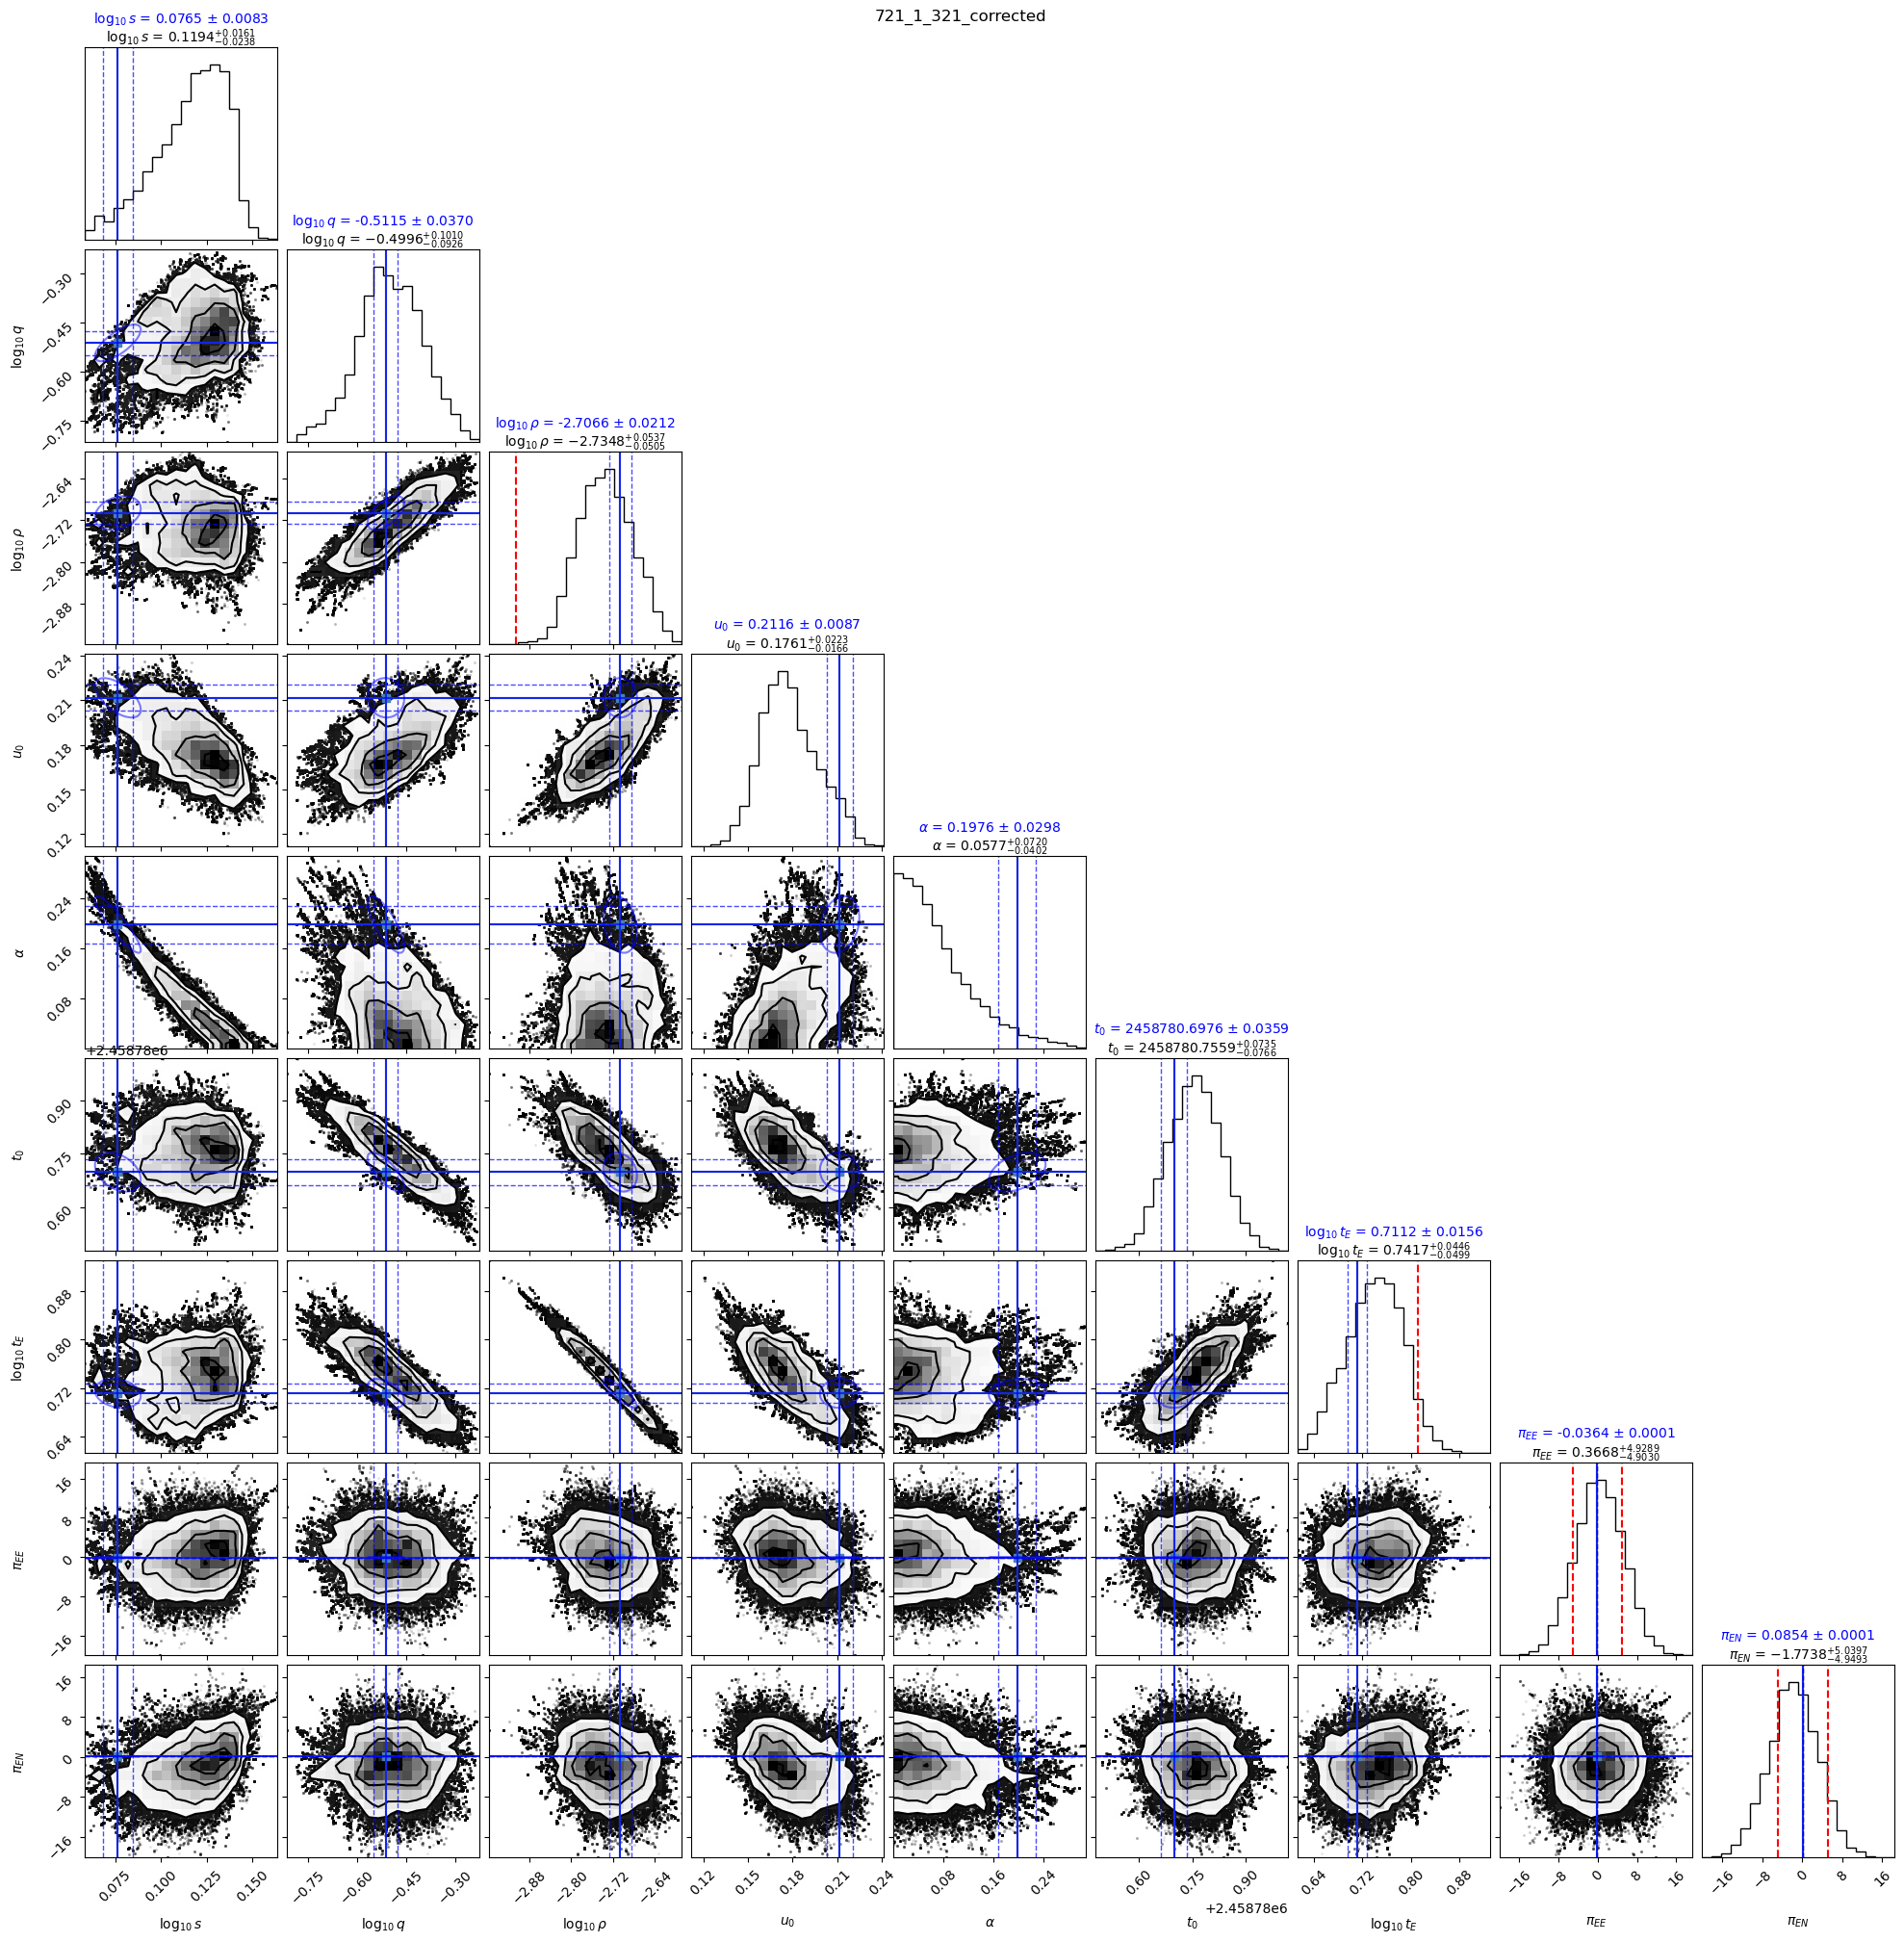

✓ Fisher corner plot displayed!
✓ Covariance source: Full inverse block
✓ Truth values and uncertainties now in consistent parameter spaces


In [32]:
# Test the corrected corner_post function with consistent parameter spaces
if samples is not None and hasattr(data_obj, 'full_fisher_matrix') and data_obj.full_fisher_matrix is not None:
    print("Creating corrected Fisher corner plot with consistent parameter spaces...")
    
    # Use the full covariance matrix and extract the model parameter block
    n_model_params = 9
    model_fisher_cov_full = data_obj.full_covariance[:n_model_params, :n_model_params]
    model_fisher_unc_full = np.sqrt(np.diag(model_fisher_cov_full))

    # Try Schur covariance if available
    model_fisher_cov_schur = getattr(data_obj, 'schur_covariance_alt', None)
    if model_fisher_cov_schur is not None and model_fisher_cov_schur.shape != model_fisher_cov_full.shape:
        model_fisher_cov_schur = None  # shape mismatch safeguard

    # Toggle: set to True to use Schur covariance instead of full inverse block
    USE_SCHUR_FOR_CORNER = False
    if USE_SCHUR_FOR_CORNER:
        print("Using SCHUR covariance for corner plot uncertainties/ellipses.")
    else:
        print("Using FULL-INVERSE block covariance for corner plot (Schur not available or disabled).")
    
    print(f"Truth values that will be displayed:")
    param_names_short = ['log10(s)', 'log10(q)', 'log10(rho)', 'u0', 'alpha', 't0', 'log10(tE)', 'piEE', 'piEN']
    log_params = ["s", "q", "rho", "tE"]
    
    if 'truths' in locals() and truths is not None and 'params' in truths:
        for i, (name, truth_val) in enumerate(zip(param_names_short, truths['params'][:9])):
            param_base = name.replace('log10(', '').replace(')', '')
            if param_base in log_params:
                log_truth = np.log10(truth_val) if truth_val > 0 else np.nan
                unc_full = model_fisher_unc_full[i]
                unc_active = np.sqrt(model_fisher_cov_schur[i,i]) if USE_SCHUR_FOR_CORNER else unc_full
                print(f"  {name}: linear={truth_val:.6f}, log={log_truth:.6f}, σ(full)={unc_full:.6f}, σ(active)={unc_active:.6f}")
            else:
                unc_full = model_fisher_unc_full[i]
                unc_active = np.sqrt(model_fisher_cov_schur[i,i]) if USE_SCHUR_FOR_CORNER else unc_full
                print(f"  {name}: {truth_val:.6f}, σ(full)={unc_full:.6f}, σ(active)={unc_active:.6f}")
    
    # Create a Fit object
    fit_obj = Fit()
    
    # Active uncertainty vector
    fisher_uncertainties_active = (np.sqrt(np.diag(model_fisher_cov_schur)) if USE_SCHUR_FOR_CORNER else model_fisher_unc_full)

    # Call corner_post with Schur option
    fig = fit_obj.corner_post(
        samples=samples,
        event_name=f"{event_name}_corrected",
        path="./",
        truths=truths,
        fisher_covariance=model_fisher_cov_full,
        fisher_covariance_schur=model_fisher_cov_schur,
        fisher_uncertainties=fisher_uncertainties_active,
        log_param_names=log_params,  # s, q, rho, tE
        k2=2.30,  # 68% confidence ellipses
        return_figure=True,
        use_schur=USE_SCHUR_FOR_CORNER
    )
    
    # indicate prior sigmas (load from prior_config section in yaml: <event_id>_sampling.prm)
    prior_sigmas = {
        'sigma_logs': 0.5,
        'sigma_logq': 0.5,
        'sigma_logrho': 0.2,
        'sigma_u0' : 0.5,
        'sigma_alpha': 0.5,
        'sigma_t0': 0.5,
        'sigma_logtE': 0.1,
        'sigma_piEE': 5.0,
        'sigma_piEN': 5.0,
        'sigma_t0': 0.5
    }

    # Overlay prior sigmas (truth+sigma and truth-sigma) as red dashed lines on the diagonal axes
    truth_params = truths['params']
    for i, (param, prior_sigma) in enumerate(prior_sigmas.items()):
        if prior_sigma is not None:
            print(f"  {param}: σ(prior)={prior_sigma:.6f}")
            truth = truth_params[i]
            if "log" in param:
                truth = np.log10(truth) if truth > 0 else np.nan
            lower = truth - prior_sigma
            upper = truth + prior_sigma
            if i < len(fig.axes):
                ax = fig.axes[i * (len(prior_sigmas) + 1)]  # diagonal axes in corner plot
                ax.axvline(x=lower, color='red', linestyle='--', label='Prior σ')
                ax.axvline(x=upper, color='red', linestyle='--')
                print(f"    Overlayed prior sigma lines at {lower:.6f} and {upper:.6f} on axis {i}")

    # Display the figure in the notebook
    plt.show()
    
    print("✓ Fisher corner plot displayed!")
    print(f"✓ Covariance source: {'Schur' if USE_SCHUR_FOR_CORNER else 'Full inverse block'}")
    print("✓ Truth values and uncertainties now in consistent parameter spaces")
else:
    print("Cannot create corrected corner plot - missing samples or Fisher matrix")

### Again with the Schur Method Uncertainties

Creating corrected Fisher corner plot with consistent parameter spaces...
Using SCHUR covariance for corner plot uncertainties/ellipses.
Truth values that will be displayed:
  log10(s): linear=1.192541, log=0.076473, σ(full)=0.008272, σ(active)=0.009632
  log10(q): linear=0.307936, log=-0.511540, σ(full)=0.037035, σ(active)=0.041204
  log10(rho): linear=0.001965, log=-2.706582, σ(full)=0.021160, σ(active)=0.027113
  u0: 0.211575, σ(full)=0.008731, σ(active)=0.009385
  alpha: 0.197640, σ(full)=0.029754, σ(active)=0.045723
  t0: 2458780.697566, σ(full)=0.035891, σ(active)=0.051418
  log10(tE): linear=5.143039, log=0.711220, σ(full)=0.015626, σ(active)=0.017506
  piEE: -0.036441, σ(full)=0.000092, σ(active)=16.837742
  piEN: 0.085357, σ(full)=0.000113, σ(active)=12.443133
Checking for log parameter: s
Replacing $\log_{10}s$ with log10
Checking for log parameter: q
Replacing $\log_{10}q$ with log10
Checking for log parameter: rho
Replacing $\log_{10}{\rho}$ with log10
Checking for log para

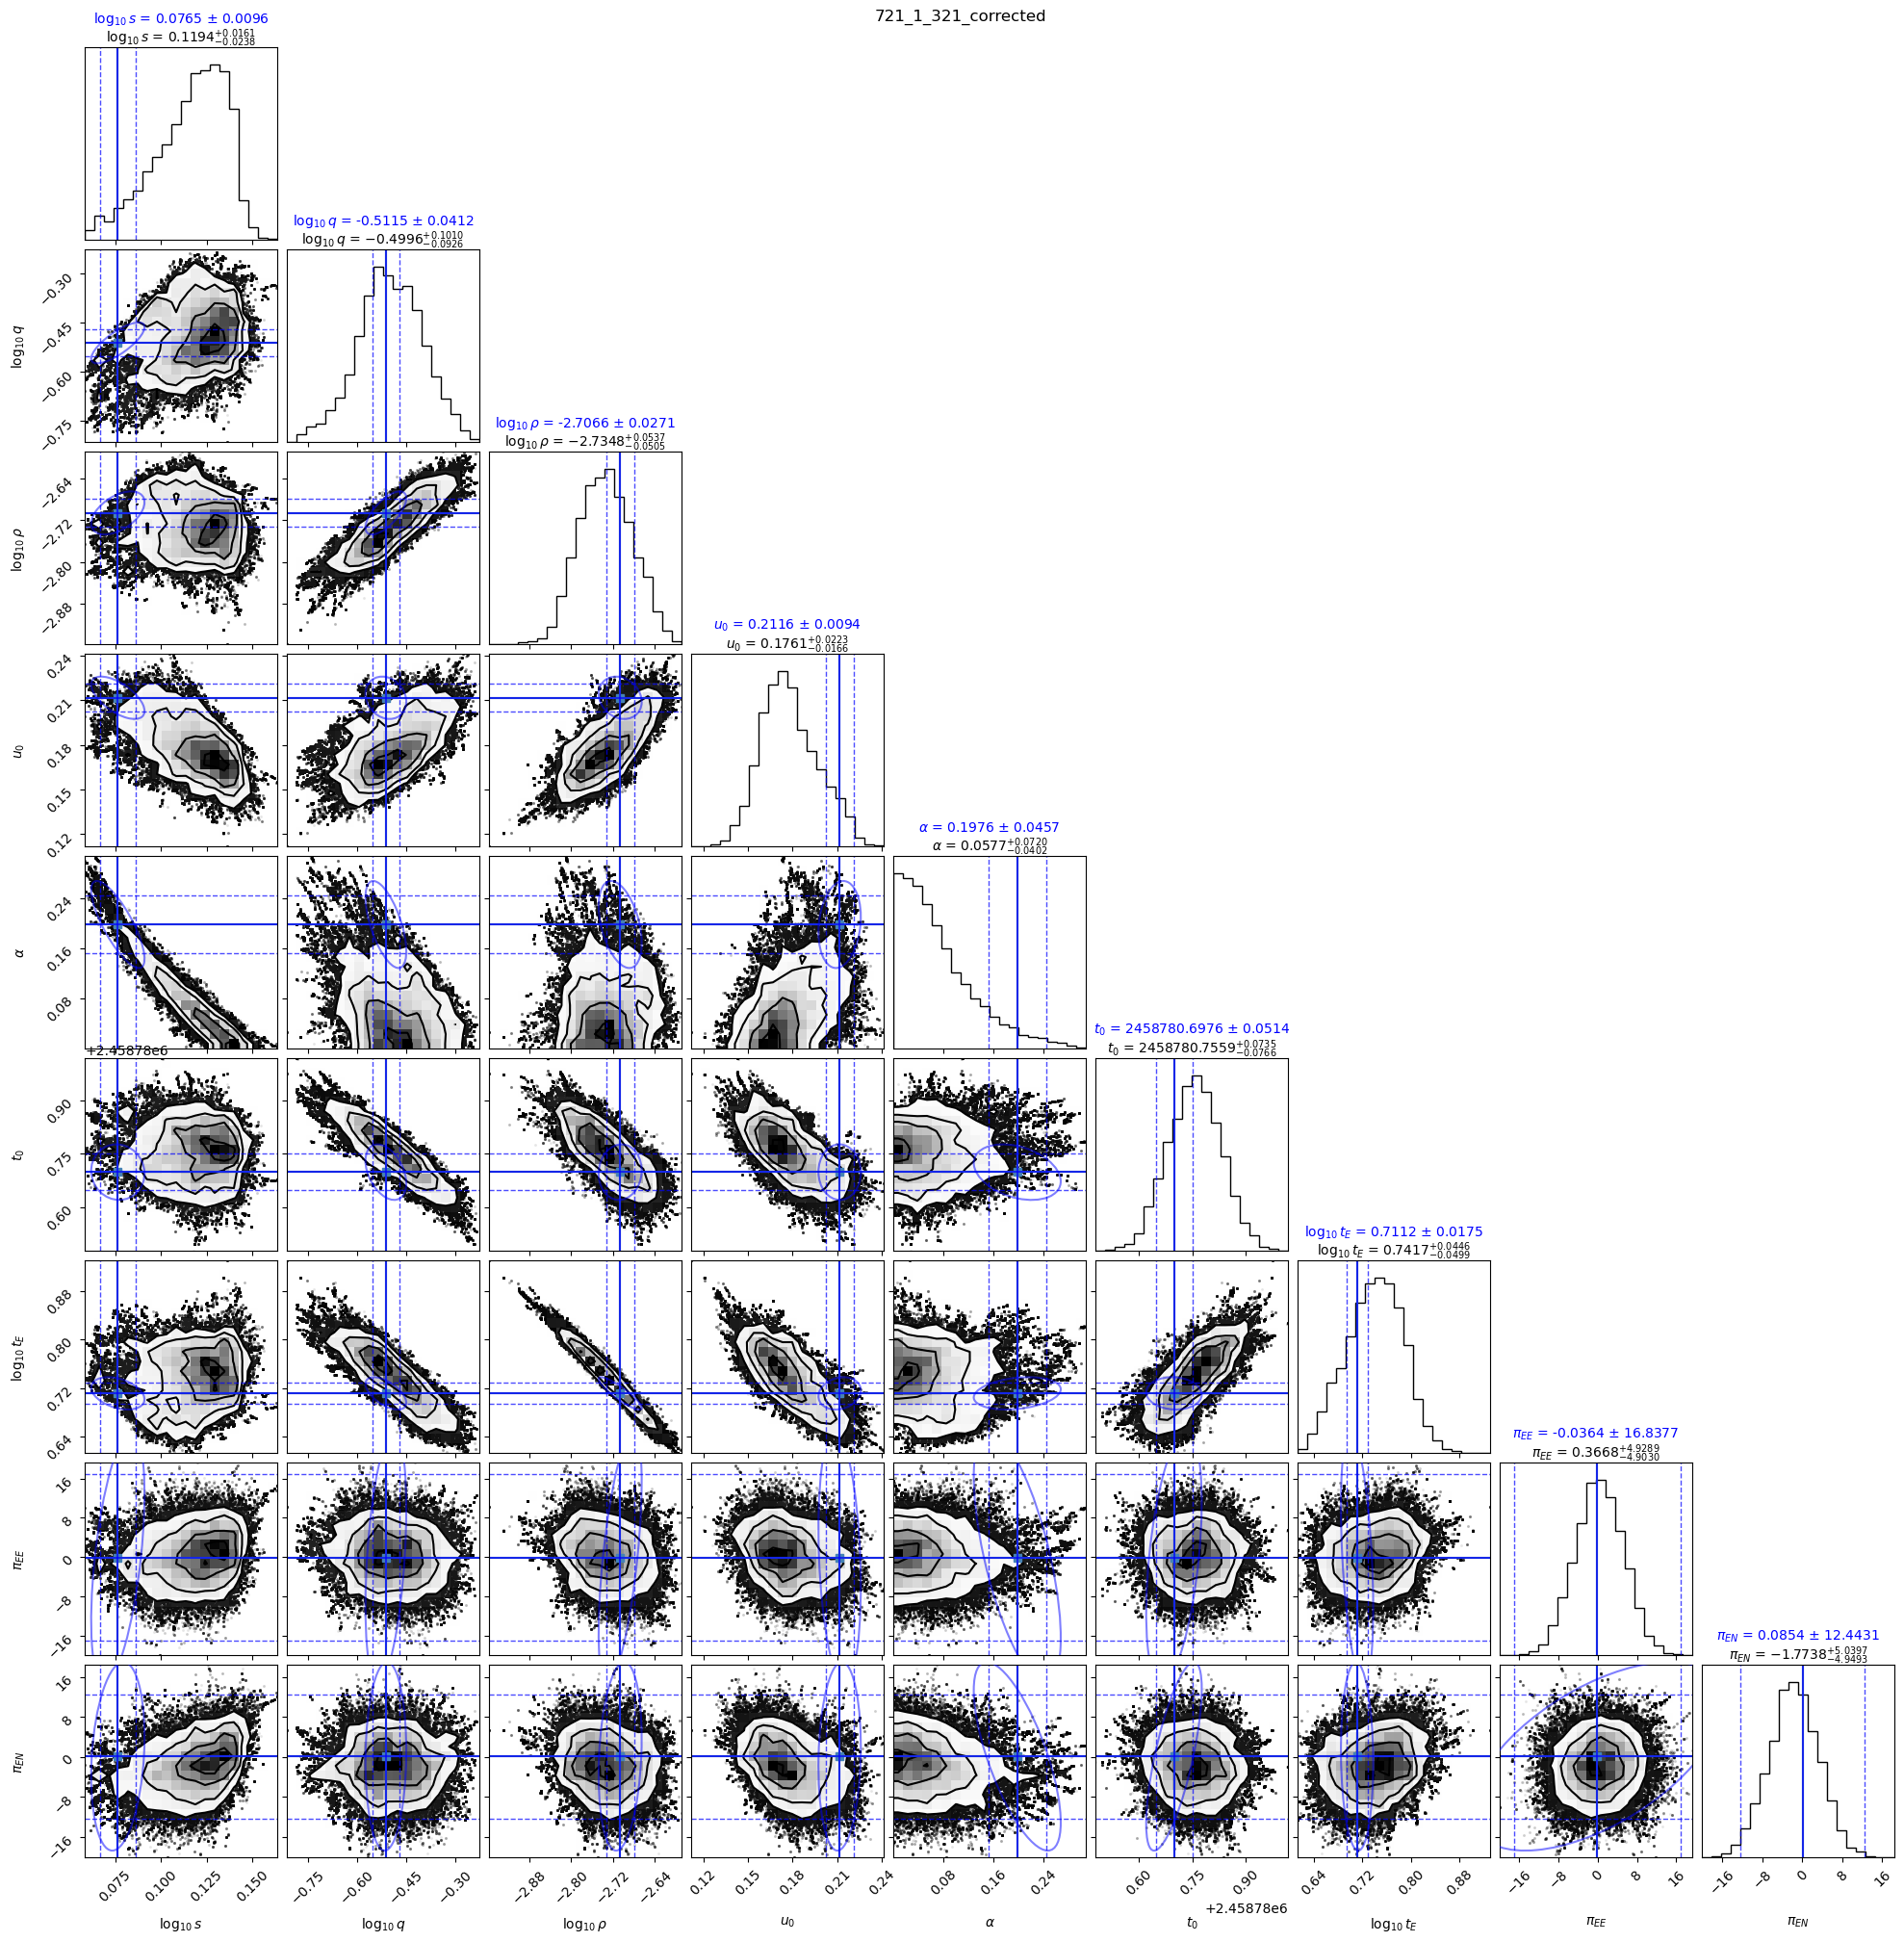

✓ Fisher corner plot displayed!
✓ Covariance source: Schur
✓ Truth values and uncertainties now in consistent parameter spaces


In [33]:
# Corner plot
# Test the corrected corner_post function with consistent parameter spaces
if samples is not None and hasattr(data_obj, 'full_fisher_matrix') and data_obj.full_fisher_matrix is not None:
    print("Creating corrected Fisher corner plot with consistent parameter spaces...")
    
    # Use the full covariance matrix and extract the model parameter block
    n_model_params = 9
    model_fisher_cov_full = data_obj.full_covariance[:n_model_params, :n_model_params]
    model_fisher_unc_full = np.sqrt(np.diag(model_fisher_cov_full))

    # Try Schur covariance if available
    model_fisher_cov_schur = getattr(data_obj, 'schur_covariance_alt', None)
    if model_fisher_cov_schur is not None and model_fisher_cov_schur.shape != model_fisher_cov_full.shape:
        model_fisher_cov_schur = None  # shape mismatch safeguard

    # Toggle: set to True to use Schur covariance instead of full inverse block
    USE_SCHUR_FOR_CORNER = True if model_fisher_cov_schur is not None else False
    if USE_SCHUR_FOR_CORNER:
        print("Using SCHUR covariance for corner plot uncertainties/ellipses.")
    else:
        print("Using FULL-INVERSE block covariance for corner plot (Schur not available or disabled).")
    
    print(f"Truth values that will be displayed:")
    param_names_short = ['log10(s)', 'log10(q)', 'log10(rho)', 'u0', 'alpha', 't0', 'log10(tE)', 'piEE', 'piEN']
    log_params = ["s", "q", "rho", "tE"]
    
    if 'truths' in locals() and truths is not None and 'params' in truths:
        for i, (name, truth_val) in enumerate(zip(param_names_short, truths['params'][:9])):
            param_base = name.replace('log10(', '').replace(')', '')
            if param_base in log_params:
                log_truth = np.log10(truth_val) if truth_val > 0 else np.nan
                unc_full = model_fisher_unc_full[i]
                unc_active = np.sqrt(model_fisher_cov_schur[i,i]) if USE_SCHUR_FOR_CORNER else unc_full
                print(f"  {name}: linear={truth_val:.6f}, log={log_truth:.6f}, σ(full)={unc_full:.6f}, σ(active)={unc_active:.6f}")
            else:
                unc_full = model_fisher_unc_full[i]
                unc_active = np.sqrt(model_fisher_cov_schur[i,i]) if USE_SCHUR_FOR_CORNER else unc_full
                print(f"  {name}: {truth_val:.6f}, σ(full)={unc_full:.6f}, σ(active)={unc_active:.6f}")
    
    # Create a Fit object
    fit_obj = Fit()
    
    # Active uncertainty vector
    fisher_uncertainties_active = (np.sqrt(np.diag(model_fisher_cov_schur)) if USE_SCHUR_FOR_CORNER else model_fisher_unc_full)

    # Call corner_post with Schur option
    fig = fit_obj.corner_post(
        samples=samples,
        event_name=f"{event_name}_corrected",
        path="./",
        truths=truths,
        fisher_covariance=model_fisher_cov_full,
        fisher_covariance_schur=model_fisher_cov_schur,
        fisher_uncertainties=fisher_uncertainties_active,
        log_param_names=log_params,  # s, q, rho, tE
        k2=2.30,  # 68% confidence ellipses
        return_figure=True,
        use_schur=USE_SCHUR_FOR_CORNER
    )
    
    # Display the figure in the notebook
    plt.show()
    
    print("✓ Fisher corner plot displayed!")
    print(f"✓ Covariance source: {'Schur' if USE_SCHUR_FOR_CORNER else 'Full inverse block'}")
    print("✓ Truth values and uncertainties now in consistent parameter spaces")
else:
    print("Cannot create corrected corner plot - missing samples or Fisher matrix")



## 9. Export Results

Save processed data and analysis results:

In [34]:
# Save the lightcurve DataFrame if you want
if 'combined_df' in locals() and event_name:
    output_file = f"{event_name}_lightcurve_data.csv"
    combined_df.to_csv(output_file, index=False)
    print(f"Lightcurve data saved to: {output_file}")

# Save Fisher matrix information if available
if hasattr(data_obj, 'model_covariance') and data_obj.model_covariance is not None and event_name:
    fisher_output = {
        'covariance': fisher_cov,
        'uncertainties': fisher_unc,
        'correlation': fisher_corr,
        'parameter_names': param_names
    }
    
    fisher_file = f"{event_name}_fisher_info.pkl"
    with open(fisher_file, 'wb') as f:
        pickle.dump(fisher_output, f)
    print(f"Fisher information saved to: {fisher_file}")

print("\nNotebook execution complete!")
print("You can now experiment with the Fisher stuff in the cells above.")

Lightcurve data saved to: 721_1_321_lightcurve_data.csv


NameError: name 'fisher_cov' is not defined